<a href="https://colab.research.google.com/github/AndrewNK1/E-commerce-customer-segmentation/blob/main/Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **E-commerce Customer Segmentation for Strategic Growth**

In this notebook, we embark on a transformative journey to bridge the gap between high-level business strategy and granular data execution. Our mission is to translate the abstract business goal of "proactive, customer-centric marketing" into a concrete, technical reality.


We begin by ingesting raw transactional data—a chaotic and unorganized ledger of over half a million distinct events—which, while rich in potential, offers little immediate value in its native state. Through a rigorous process of digital hygiene, feature engineering, and advanced statistical modeling, we transmute this noise into a clean, mathematical framework. By quantifying complex human actions into precise metrics of Recency, Frequency, and Monetary (RFM) value, we enable the computer to objectively group customers by their actual purchasing behavior rather than intuition. This process turns a static spreadsheet into a dynamic engine for decision-making, allowing the business to stop guessing and start targeting with precision.


# Data Loading and Preprocessing

We first start the analysis by importing all needed packages and loading our dataset "data.csv"


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Then we read the dataset that we uploaded, the encoding='latin1' part tells the computer how to translate the raw file data into readable text.

In [ ]:
df = pd.read_csv('data.csv', encoding='latin1')


Here we show the first and last five rows in our dataframe to understand a sample of our data.

In [ ]:
display(df.head())
display(df.tail())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/2011 12:50,4.95,12680.0,France


The `df.info()` command provides a concise summary of the DataFrame. It shows the number of entries, the total number of columns, the column names, the count of non-null values for each column, the data type (Dtype) of each column, and the memory usage. This is crucial for understanding the structure and initial data quality of the DataFrame.

In this particular output:
- **`RangeIndex: 541909 entries, 0 to 541908`**: Indicates that the DataFrame has 541,909 rows, indexed from 0 to 541,908.
- **`Data columns (total 8 columns)`**: There are 8 columns in total.
- **Column details (e.g., `InvoiceNo 541909 non-null object`):** This section lists each column, its count of non-null values, and its data type. For example, `InvoiceNo` has 541,909 non-null entries and is of `object` type (typically strings). Notice that `Description` and `CustomerID` have fewer non-null entries than the total number of rows, indicating missing values in those columns.
- **`dtypes: float64(2), int64(1), object(5)`**: Summarizes the data types present: 2 columns are `float64`, 1 is `int64`, and 5 are `object`.
- **`memory usage: 33.1+ MB`**: Shows the memory consumed by the DataFrame.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


The dataset initially contained 541,909 rows and 8 columns.

In [ ]:
df.shape

(541909, 8)

A necessary correction was made for the InvoiceNo column due to an issue in its name.


In [ ]:
df.rename(columns={'ï»¿InvoiceNo':'InvoiceNo'},inplace=True)

In [ ]:
#Here we are displaying the data types of the columns available.
display(df.dtypes)

,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,object
UnitPrice,float64
CustomerID,float64
Country,object


The InvoiceDate column was successfully converted to the datetime format for time-series analysis.

In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


Missing values in the CustomerID and Description columns, were dropped to ensure the dataset was suitable for further analysis.

In [ ]:
display(df.isnull().sum())


,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
#Here we remove the nulls in our data and we show the number of nulls in the data after removing them.
df = df.dropna()
display(df.isnull().sum())



,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


Now we check for duplicate rows in our dataset

In [ ]:
print(f"Number of duplicate rows: {df.duplicated().sum()}")

# Display all duplicate rows, including their first occurrence
# Set `keep=False` to mark all duplicates as True
duplicate_rows = df[df.duplicated(keep=False)]

if not duplicate_rows.empty:
    print("\nSample of duplicate rows:")
    display(duplicate_rows.sort_values(by=list(df.columns)).head(10)) # Display first 10 for brevity
else:
    print("No duplicate rows found.")

Number of duplicate rows: 5225

Sample of duplicate rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
578,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920.0,United Kingdom
598,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920.0,United Kingdom


In [ ]:
#removing duplicates and we check that they have been removed by printing the number of duplicates in our data.
df.drop_duplicates(inplace=True)
print(f"Number of duplicate rows after dropping: {df.duplicated().sum()}")

Number of duplicate rows after dropping: 0


According to the logic of our dataset and business case, we have transactions that are not meaningful or useful because they are cancelled. Thus we are going to check for the transactions that are cancelled and after that we remove them. In the following code we check for the number of cancelled transactions and the shape of the dataset before removing them.


In [ ]:
df['Transaction_Status'] = np.where(df['InvoiceNo'].astype(str).str.startswith('C'), 'Cancelled', 'Completed')

# Analyze the characteristics of these rows (considering the new column)
cancelled_transactions = df[df['Transaction_Status'] == 'Cancelled']
print(f"Number of cancelled transactions: {len(cancelled_transactions)}")
#Shape before dropping cancelled transactions
print(f"New shape of DataFrame before removing cancelled transactions: {df.shape}")

Number of cancelled transactions: 8872
New shape of DataFrame before removing cancelled transactions: (401604, 9)


In [ ]:
# Get the indices of cancelled transactions from the previously identified DataFrame
cancelled_indices = cancelled_transactions.index

# Drop these rows from the main DataFrame df
df = df.drop(cancelled_indices)

print(f"New shape of DataFrame after removing cancelled transactions: {df.shape}")

New shape of DataFrame after removing cancelled transactions: (392732, 9)


After cleaning, the dataset retained 392732 rows, representing all fully recorded transactions.

# **Exploratory Data Analysis (EDA)**

Our initial exploration revealed key patterns in sales volume, geographic distribution, and revenue trends, setting the context for the segmentation modeling.

**A. Correlation Heatmap**:

The heatmap reveals the correlation relationships among three variables: Quantity, UnitPrice, and TotalAmount. Quantity and TotalAmount exhibit a nearly perfect positive correlation (0.99), indicating that as the quantity of items increases, the total amount tends to increase proportionally—likely because TotalAmount is derived from Quantity multiplied by UnitPrice. In contrast, UnitPrice shows virtually no correlation with either Quantity (-0.00) or TotalAmount (-0.01), suggesting that price variations are independent of how much is purchased or the resulting transaction value. This pattern highlights that Quantity is the dominant driver of TotalAmount in this dataset.

In [ ]:
# Calculate TotalAmount before proceeding with EDA and RFM feature engineering
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

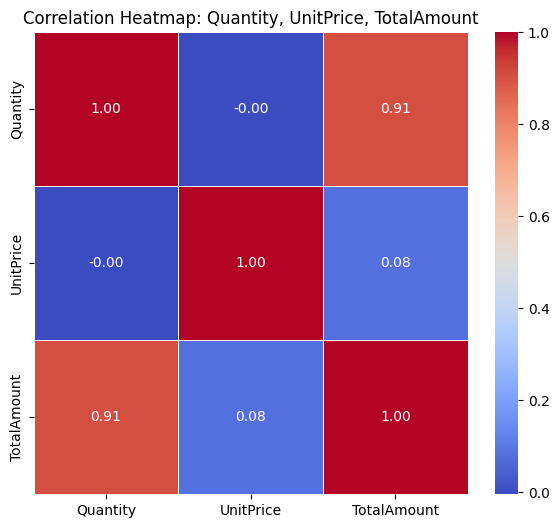

In [ ]:
#Here we create a heatmap showing the correlation between Quantity, unitprice and Total amount.
numeric_cols_for_heatmap = ['Quantity', 'UnitPrice', 'TotalAmount']
correlation_matrix_specific = df[numeric_cols_for_heatmap].corr()
plt.figure(figsize=(7, 6))
sns.heatmap(correlation_matrix_specific, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap: Quantity, UnitPrice, TotalAmount')
plt.show()

After cleaning, the dataset retained 392732 rows, representing all fully recorded transactions.

**B. Most Frequent Stocks:**

displays the percentage frequency of the most commonly occurring product codes in the dataset. The stock code 85123A is the most frequent, appearing in 0.51% of all transactions, followed closely by 22423 and 85099B, each contributing between 0.41%–0.47%. The remaining codes range from 0.27% to 0.35%, indicating a relatively even distribution among popular items. The inverted y-axis places the most frequent codes at the top, enhancing readability. This visualization highlights which products dominate the inventory or sales activity, offering insights into customer purchasing patterns and potential stocking priorities.

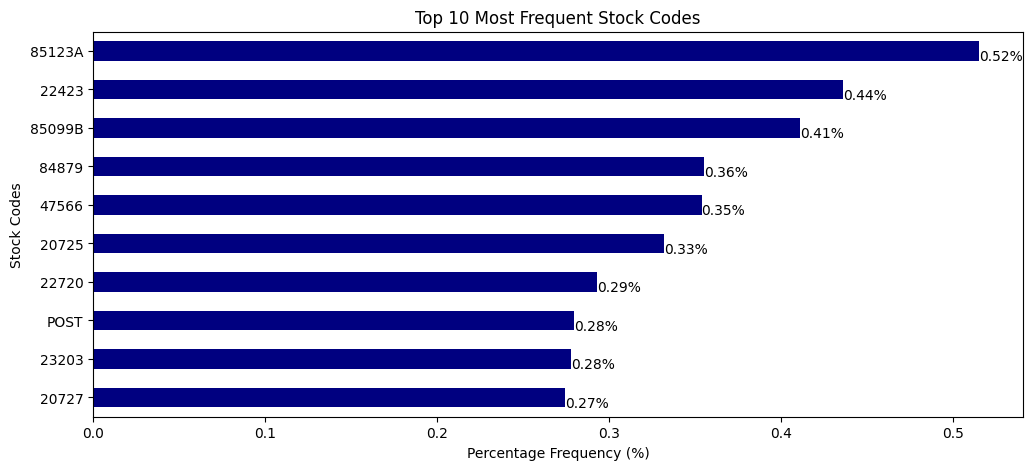

In [ ]:
# Finding the top 10 most frequent stock codes
top_10_stock_codes = df['StockCode'].value_counts(normalize=True).head(10) * 100

# Plotting the top 10 most frequent stock codes
plt.figure(figsize=(12, 5))
top_10_stock_codes.plot(kind='barh', color='#000080')

# Adding the percentage frequency on the bars
for index, value in enumerate(top_10_stock_codes):
    plt.text(value, index+0.25, f'{value:.2f}%', fontsize=10)

plt.title('Top 10 Most Frequent Stock Codes')
plt.xlabel('Percentage Frequency (%)')
plt.ylabel('Stock Codes')
plt.gca().invert_yaxis()
plt.show()

**C. Geographic Customer Distribution:**

This is a bar plot of unique customers by country, which confirms the business's primary focus.

The United Kingdom is overwhelmingly the dominant market, contributing 3,950 unique customers, significantly more than any other country.

The remaining top countries (including Germany, France, and Spain) form a smaller, but important, international customer base.


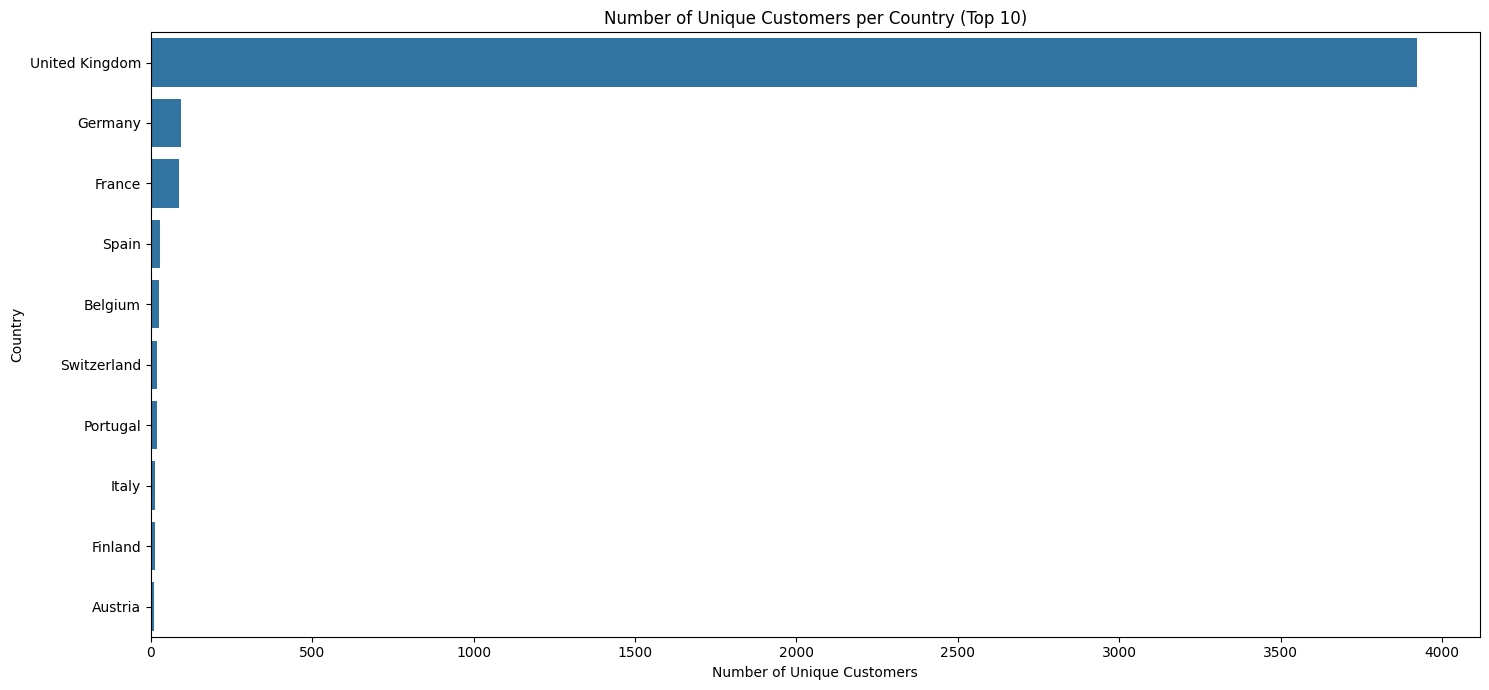

In [ ]:
country_customer_counts = df.groupby('Country')['CustomerID'].nunique().reset_index()
country_customer_counts = country_customer_counts.sort_values(by='CustomerID', ascending=False)

plt.figure(figsize=(15, 7))
sns.barplot(x='CustomerID', y='Country', data=country_customer_counts.head(10))
plt.title('Number of Unique Customers per Country (Top 10)')
plt.xlabel('Number of Unique Customers')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

**D. Monthly Revenue Trends:**

To understand the most critical revenue streams, a time-series plot of monthly total revenue was generated for the top 5 revenue-generating countries: United Kingdom, Netherlands, EIRE, Germany, and France.

The United Kingdom (UK), as expected, drives the vast majority of the revenue. The plot shows a strong and consistent upward trend over the year, culminating in a massive spike in the final months of the year, reinforcing the holiday sales effect.

Other Top Countries, while smaller,show relatively steady and significant contributions. The stability of these secondary markets indicates healthy international sales.

Overall, The revenue patterns confirm the business is highly dependent on the UK market, particularly during the peak shopping season, while international sales provide a solid, consistent base.

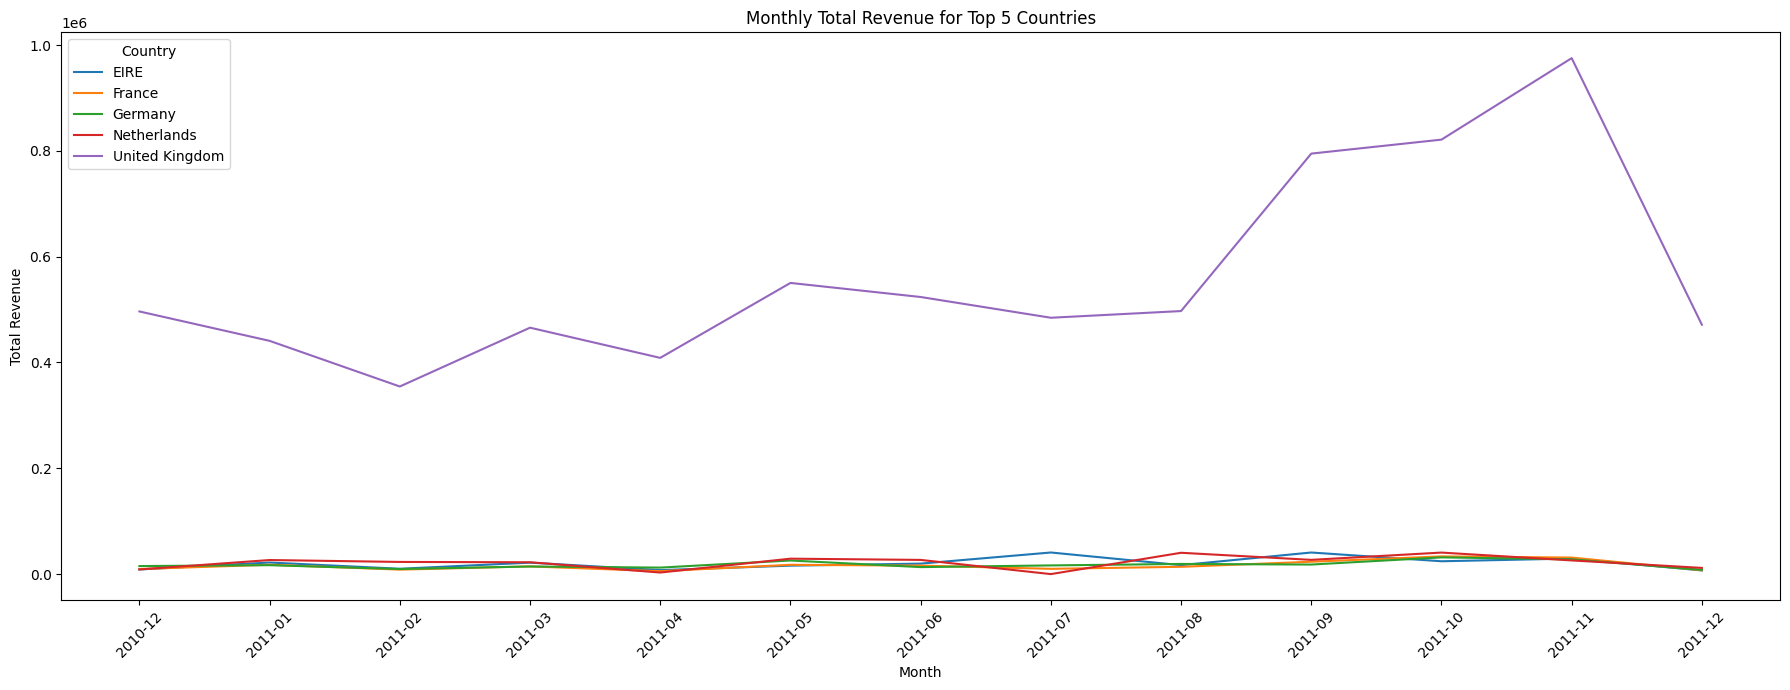

In [ ]:
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
monthly_revenue = df.groupby(['YearMonth', 'Country'])['TotalAmount'].sum().reset_index()
top_5_countries = monthly_revenue.groupby('Country')['TotalAmount'].sum().nlargest(5).index
monthly_revenue_top5 = monthly_revenue[monthly_revenue['Country'].isin(top_5_countries)]

monthly_revenue_top5 = monthly_revenue_top5.copy()
monthly_revenue_top5['YearMonth'] = monthly_revenue_top5['YearMonth'].astype(str)

plt.figure(figsize=(18, 7))
sns.lineplot(x='YearMonth', y='TotalAmount', hue='Country', data=monthly_revenue_top5)
plt.title('Monthly Total Revenue for Top 5 Countries')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.legend(title='Country')
plt.tight_layout()
plt.show()

This foundational understanding of the data's volume, geography, and time-series trends now provides us the context for building the RFM-Based Clustering Model to strategically segment the customer base.

# **Feature Engineering: Feauture Construction**
RFM-Based Clustering Model

RFM stands for Recency, Frequency, and Monetary — three customer-behavior metrics widely used in customer segmentation and CRM analytics.

Recency (R):
Measures how recently a customer made a purchase.
Lower values → more recent → more engaged customers.

Frequency (F):
Counts how often a customer makes purchases in a given period.
Higher values → repeat buyers → higher loyalty.

Monetary (M):
Represents the total spending of a customer.
Higher values → high-value customers.

RFM helps summarize purchasing behaviour in three simple metrics before applying clustering.


Before clustering, we compute the RFM metrics

In [ ]:
latest_date = df['InvoiceDate'].max() + pd.DateOffset(days=1)
constructed_df = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda date: (latest_date - date.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalAmount', 'sum')
).reset_index()
constructed_df

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40
...,...,...,...,...
4334,18280.0,278,1,180.60
4335,18281.0,181,1,80.82
4336,18282.0,8,2,178.05
4337,18283.0,4,16,2045.53


# Preprocessing and Exploratory Data Analysis (EDA)
We will Explore our new features using descriptive statistics and visualize it using Boxplots & Histogram for the distribution.


Cleaning the data by:
Removing negative/zero values
Removing extreme outliers if necessary
This ensures the clustering model receives consistent and reliable inputs.

In [ ]:
#Check for null vales
constructed_df.isnull().sum()


,0
CustomerID,0
Recency,0
Frequency,0
Monetary,0


In [ ]:
#Checked for negative values in Monetary
print(constructed_df[constructed_df['Monetary'] < 0].shape[0])

0


In [ ]:
#Checked for negative values in Frequency
print(constructed_df[constructed_df['Frequency'] < 0].shape[0])

0


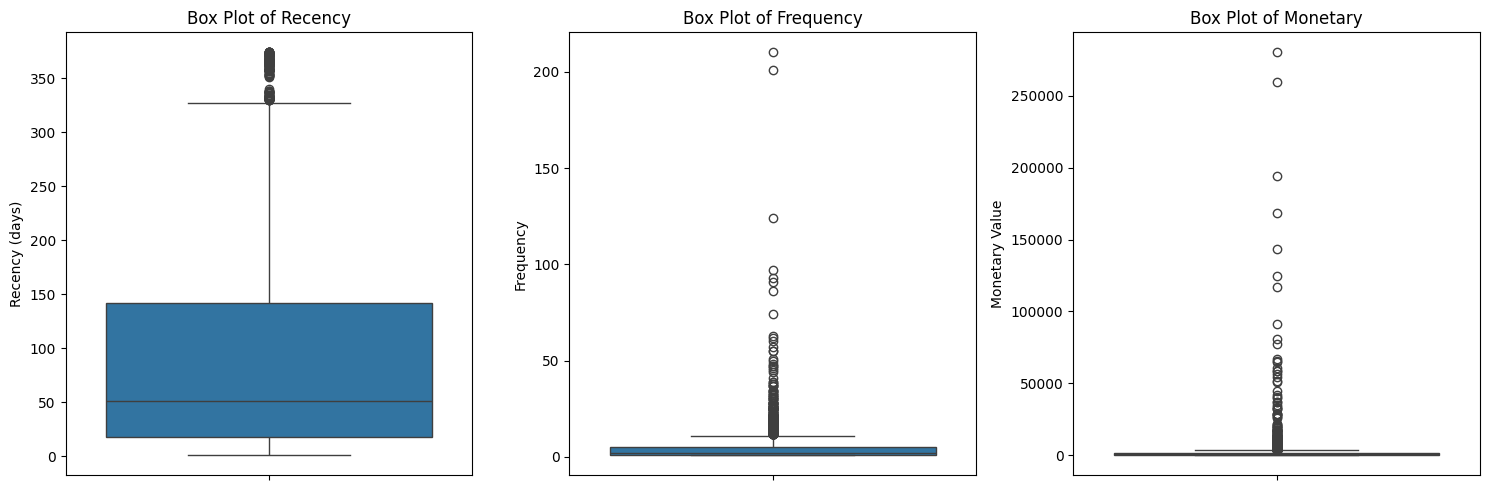

In [ ]:
#Producing BoxPlots to visulaize outliers
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=constructed_df['Recency'])
plt.title('Box Plot of Recency')
plt.ylabel('Recency (days)')

plt.subplot(1, 3, 2)
sns.boxplot(y=constructed_df['Frequency'])
plt.title('Box Plot of Frequency')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
sns.boxplot(y=constructed_df['Monetary'])
plt.title('Box Plot of Monetary')
plt.ylabel('Monetary Value')

plt.tight_layout()
plt.show()

We tried to handle the outliers with winsorization but this method ruined the meaningful data from the dataset and increased the outliers.


Descriptive Statistics for RFM features:
           Recency    Frequency       Monetary
count  4339.000000  4339.000000    4339.000000
mean     92.518322     4.271952    2048.215924
std     100.009747     7.705493    8984.248352
min       1.000000     1.000000       0.000000
25%      18.000000     1.000000     306.455000
50%      51.000000     2.000000     668.560000
75%     142.000000     5.000000    1660.315000
max     374.000000   210.000000  280206.020000


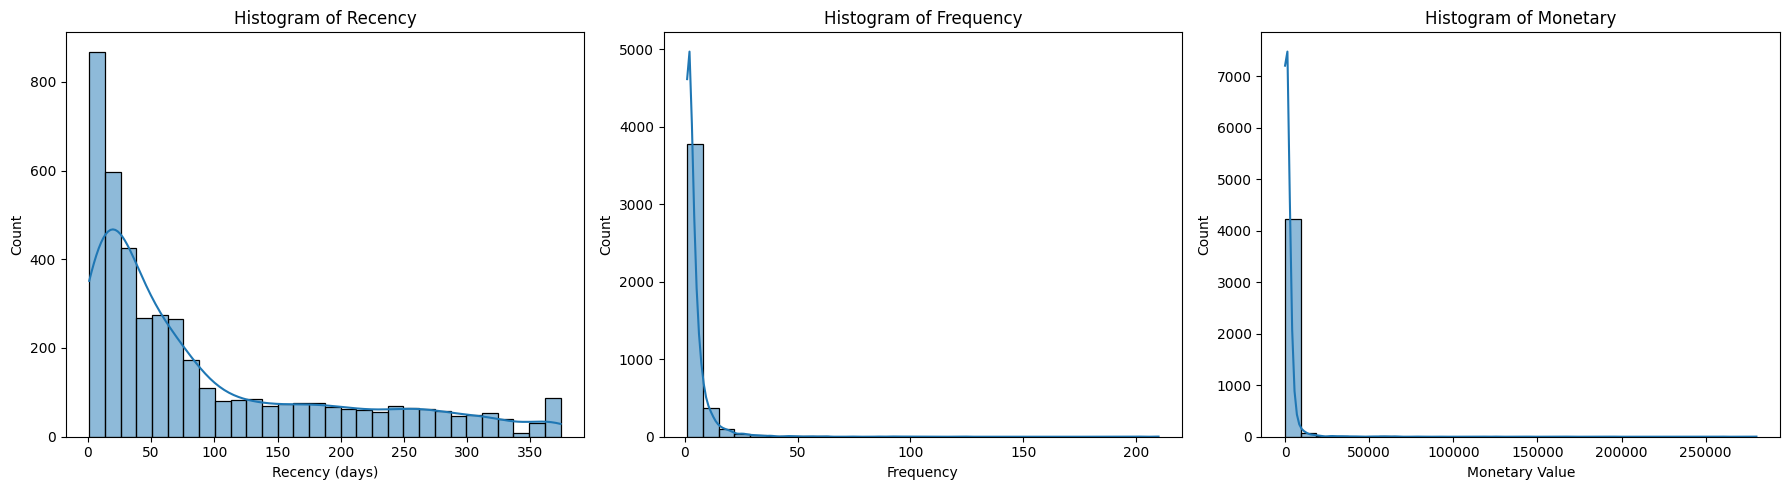

In [ ]:
#Looking into the data distribution
print('Descriptive Statistics for RFM features:')
print(constructed_df[['Recency', 'Frequency', 'Monetary']].describe())

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.histplot(constructed_df['Recency'], bins=30, kde=True)
plt.title('Histogram of Recency')
plt.xlabel('Recency (days)')
plt.ylabel('Count')

plt.subplot(1, 3, 2)
sns.histplot(constructed_df['Frequency'], bins=30, kde=True)
plt.title('Histogram of Frequency')
plt.xlabel('Frequency')
plt.ylabel('Count')

plt.subplot(1, 3, 3)
sns.histplot(constructed_df['Monetary'], bins=30, kde=True)
plt.title('Histogram of Monetary')
plt.xlabel('Monetary Value')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

Skewness measures the asymmetry of a data distribution: positive indicates a longer right tail, negative a longer left tail, and zero means symmetry. This helps understand data shape, with transformations often used to achieve near-zero skewness.

In [ ]:
#Checking for Skewness
print('Skewness for Recency:', constructed_df['Recency'].skew())
print('Skewness for Frequency:', constructed_df['Frequency'].skew())
print('Skewness for Monetary:', constructed_df['Monetary'].skew())

Skewness for Recency: 1.2463568823921842
Skewness for Frequency: 12.10002786545208
Skewness for Monetary: 19.341402694657173


All features (Recency: 1.25, Frequency: 12.10, Monetary: 19.34) showed strong positive skewness, meaning most values were low, with a few extreme high values pulling the mean.

In [ ]:
#Solivng Skewness using log transformation
constructed_df['Recency'] = np.log1p(constructed_df['Recency'])
constructed_df['Frequency'] = np.log1p(constructed_df['Frequency'])
constructed_df['Monetary'] = np.log1p(constructed_df['Monetary'])

print('Skewness for Recency:', constructed_df['Recency'].skew())
print('Skewness for Frequency:', constructed_df['Frequency'].skew())
print('Skewness for Monetary:', constructed_df['Monetary'].skew())

Skewness for Recency: -0.3786768864505298
Skewness for Frequency: 1.2089173276077922
Skewness for Monetary: 0.36372785782571876


Recency became slightly negatively skewed (-0.38), while Frequency (1.21) and Monetary (0.36) remained positively skewed but were significantly less skewed than before, indicating a more normalized distribution overall.

**After preprocessing cleaning our data and applying log transformaiton we will scale our data to make all features comparable so that the clustering algorithms treats them fairly.**

In [ ]:
#Before Scaling we will copy data so we could trace them back in actual vales
X=constructed_df[['Recency', 'Frequency', 'Monetary']].copy()

In [ ]:
#Scaling our data using Robust scaling as it much less sensitive to outliers. It keeps extreme values from dominating the model without removing them.
from sklearn.preprocessing import RobustScaler
rbf_scaler = RobustScaler()
scaled_features = rbf_scaler.fit_transform(X[['Recency', 'Frequency', 'Monetary']])

X['Recency'] = scaled_features[:,0]
X['Frequency'] = scaled_features[:,1]
X['Monetary'] = scaled_features[:,2]

display(X.head())

,Recency,Frequency,Monetary
0,0.910975,-0.369070,2.814009
1,-1.413309,0.892789,1.103891
2,0.188015,0.464974,0.585609
3,-0.473399,-0.369070,0.572379
4,0.886120,-0.369070,-0.409770


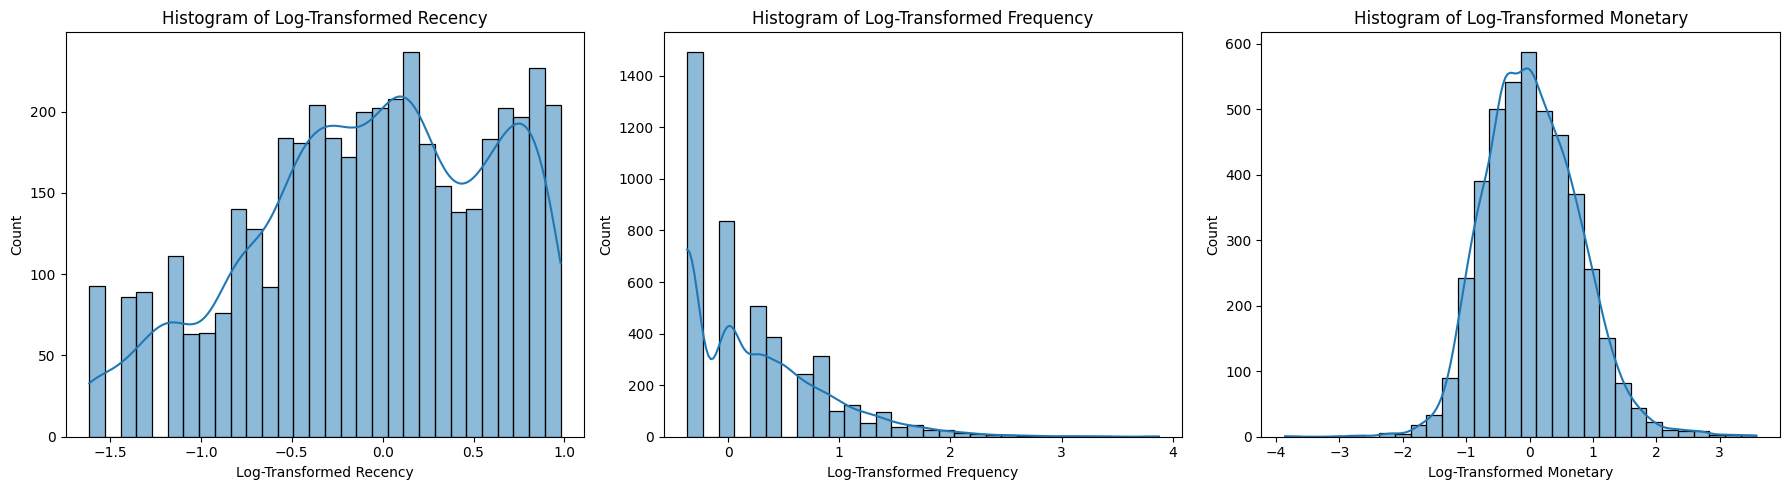

In [ ]:
#Viewing data after robust scaling & log transforming
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.histplot(X['Recency'], bins=30, kde=True)
plt.title('Histogram of Log-Transformed Recency')
plt.xlabel('Log-Transformed Recency')
plt.ylabel('Count')

plt.subplot(1, 3, 2)
sns.histplot(X['Frequency'], bins=30, kde=True)
plt.title('Histogram of Log-Transformed Frequency')
plt.xlabel('Log-Transformed Frequency')
plt.ylabel('Count')

plt.subplot(1, 3, 3)
sns.histplot(X['Monetary'], bins=30, kde=True)
plt.title('Histogram of Log-Transformed Monetary')
plt.xlabel('Log-Transformed Monetary')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

# **Bulidng the Models**

In this step, we aim to cluster our customers based on RFM features. To ensure we find the most suitable segmentation approach, we will build four different clustering models and then evaluate their performance. Each model has its strengths and weaknesses, so exploring multiple algorithms helps us make a more informed decision.


# 1. K-Means Clustering

Overview: K-Means is a centroid-based clustering algorithm that partitions data into k clusters by minimizing the distance between data points and their respective cluster centroids.

How it works:

Initialize k centroids randomly.

Assign each data point to the nearest centroid.

Recalculate centroids as the mean of assigned points.

Repeat steps 2–3 until centroids stabilize.

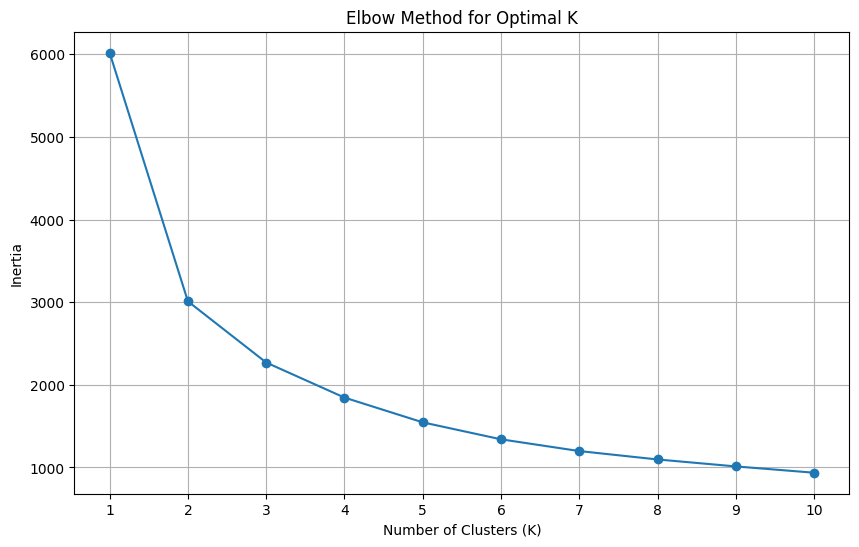

Elbow method plot generated to determine optimal number of clusters.


In [ ]:
# Calculate and plot the elbow Score know the optimal number of clusters
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), sse, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

print("Elbow method plot generated to determine optimal number of clusters.")

In [ ]:
# Used the optimal k to fit and transform our K-means Model
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
kmeans.fit(X)
constructed_df['K-Means Cluster'] = kmeans.labels_
print("\nNumber of customers per cluster:")
print(constructed_df['K-Means Cluster'].value_counts().sort_index())



Number of customers per cluster:
K-Means Cluster
0     730
1    1546
2    1226
3     837
Name: count, dtype: int64


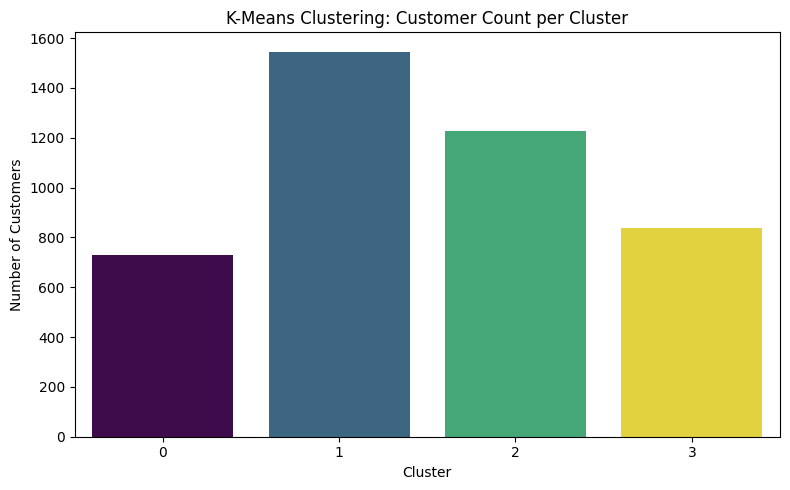

In [ ]:
#Here we show the number of customers per each cluster.
import matplotlib.pyplot as plt
import seaborn as sns

def plot_cluster_counts(df, cluster_col, title_prefix):
    cluster_counts = df[cluster_col].value_counts().sort_index()
    plt.figure(figsize=(8, 5))
    sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='viridis', hue=cluster_counts.index, legend=False)
    plt.title(f'{title_prefix}: Customer Count per Cluster')
    plt.xlabel('Cluster')
    plt.ylabel('Number of Customers')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

plot_cluster_counts(constructed_df, 'K-Means Cluster', 'K-Means Clustering')

In [ ]:
# The purpose of this code is to help interpret customer segments
# by visually profiling their average RFM behaviors (Recency, Frequency, Monetary) using bar charts.
# It also maps their spatial separation in a 3D scatter plot to assess the quality of the clustering.
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D


def plot_cluster_characteristics(df, cluster_col, title_prefix):
    cluster_means = df.groupby(cluster_col)[['Recency', 'Frequency', 'Monetary']].mean()
    print(f"\n{title_prefix} Cluster Means:")
    display(cluster_means)

    plt.figure(figsize=(18, 6))

    plt.subplot(1, 3, 1)
    cluster_means['Recency'].plot(kind='bar')
    plt.title(f'{title_prefix}: Mean Recency by Cluster')
    plt.ylabel('Mean Recency')
    plt.xlabel('Cluster')
    plt.xticks(rotation=0)

    plt.subplot(1, 3, 2)
    cluster_means['Frequency'].plot(kind='bar')
    plt.title(f'{title_prefix}: Mean Frequency by Cluster')
    plt.ylabel('Mean Frequency')
    plt.xlabel('Cluster')
    plt.xticks(rotation=0)

    plt.subplot(1, 3, 3)
    cluster_means['Monetary'].plot(kind='bar')
    plt.title(f'{title_prefix}: Mean Monetary by Cluster')
    plt.ylabel('Mean Monetary')
    plt.xlabel('Cluster')
    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()



def plot_3d_clusters(df, cluster_col, title_prefix):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Define a color palette for up to 5 clusters, more can be added if needed
    colors = sns.color_palette('viridis', n_colors=df[cluster_col].nunique())

    for i, cluster_id in enumerate(sorted(df[cluster_col].unique())):
        cluster_data = df[df[cluster_col] == cluster_id]
        ax.scatter(
            cluster_data['Recency'],
            cluster_data['Frequency'],
            cluster_data['Monetary'],
            c=colors[i] if cluster_id != -1 else 'gray', # Use gray for DBSCAN noise if present
            label=f'Cluster {cluster_id}',
            s=50, alpha=0.7
        )

    ax.set_xlabel('Recency (Scaled)')
    ax.set_ylabel('Frequency (Scaled)')
    ax.set_zlabel('Monetary (Scaled)')
    ax.set_title(f'3D Visualization of Customer Clusters ({title_prefix})')
    ax.legend()
    plt.tight_layout()
    plt.show()
    print(f"3D visualization of {title_prefix} clusters generated.")


K-Means Clustering Cluster Means:


,Recency,Frequency,Monetary
K-Means Cluster,,,
0,2.193597,2.467726,8.360986
1,5.027185,0.809643,5.518917
2,4.073985,1.518166,7.211285
3,2.691007,1.103477,6.098425


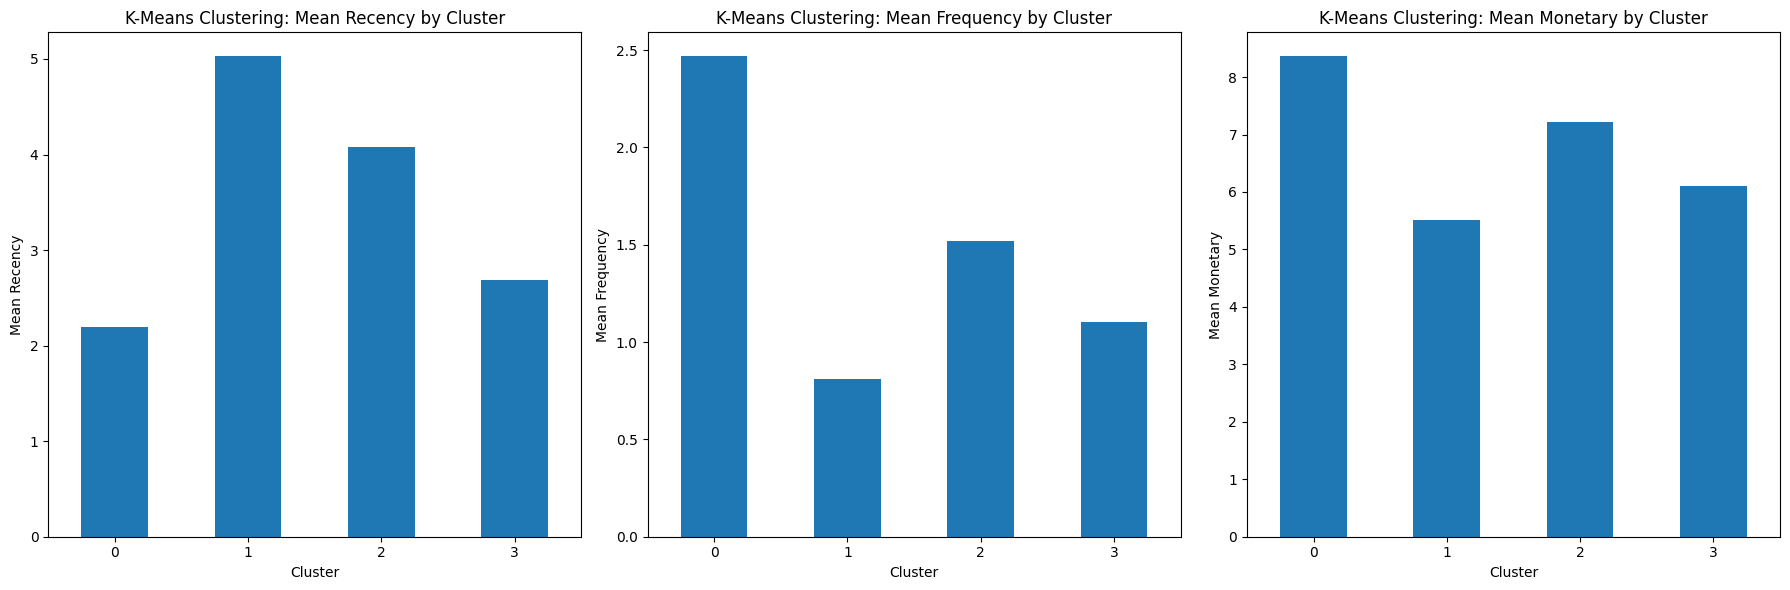

In [ ]:

# K-Means Clustering
plot_cluster_characteristics(constructed_df, 'K-Means Cluster', 'K-Means Clustering')



### K-Means Cluster Interpretation (Based on Mean RFM Values)

It's important to remember that the Recency, Frequency, and Monetary values shown here are log-transformed , meaning we should focus on their relative magnitudes to understand the customer segments.

*   **Cluster 0 (Mean Recency: 2.19, Frequency: 2.47, Monetary: 8.36)**:
    *   **Recency is low (closer to 0)**: Indicates these customers have made very recent purchases.
    *   **Frequency is high**: Suggests they buy frequently.
    *   **Monetary is high**: Shows they spend a significant amount.

*   **Cluster 1 (Mean Recency: 5.03, Frequency: 0.81, Monetary: 5.52)**:
    *   **Recency is high (further from 0)**: Implies these customers have not made a purchase recently.
    *   **Frequency is low**: Indicates they buy infrequently.
    *   **Monetary is low**: Suggests their total spending is minimal.

*   **Cluster 2 (Mean Recency: 4.07, Frequency: 1.52, Monetary: 7.21)**:
    *   **Recency is moderate**: Their last purchase was not extremely recent, but not too long ago either.
    *   **Frequency is moderate**: They purchase with some regularity but not as often as the best customers.
    *   **Monetary is moderate**: Their spending is respectable but not the highest.
    
*   **Cluster 3 (Mean Recency: 2.69, Frequency: 1.10, Monetary: 6.10)**:
    *   **Recency is low-to-moderate**: They've purchased more recently than Cluster 1 or 2, but not as recently as Cluster 0.
    *   **Frequency is low**: They don't buy very often.
    *   **Monetary is moderate**: Their total spending is moderate.
   

/tmp/ipython-input-2362437493.py:51: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(


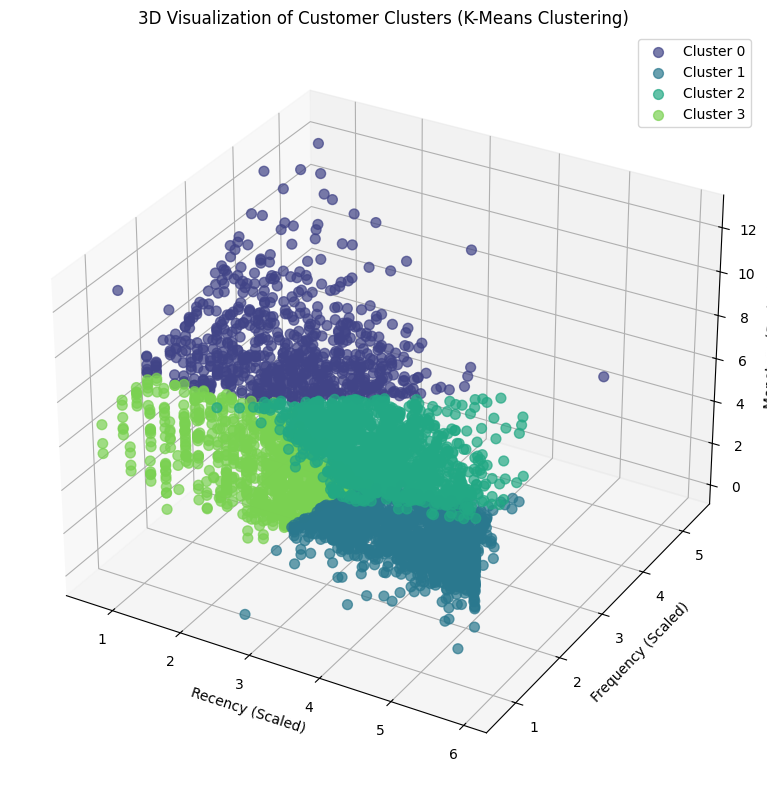

3D visualization of K-Means Clustering clusters generated.


In [ ]:
# Ploting a 3D scatter plot for our 4 clusters.
plot_3d_clusters(constructed_df, 'K-Means Cluster', 'K-Means Clustering')

Based on the K-Means clustering analysis, I've interpreted the characteristics of each customer cluster:

**K-Means Clustering Interpretation:**

- **Cluster 0:** This cluster is characterized by high Recency, low Frequency, and low Monetary values. These customers have not made a purchase recently, buy infrequently, and spend little. They might represent **"at-risk"** or **"churned"** customers who require re-engagement strategies.

- **Cluster 1:** This cluster shows low Recency, high Frequency, and high Monetary values. These are your most recent, frequent, and high-spending customers, representing your **"best customers"** or **"loyal customers."** They are highly valuable and should be prioritized for retention and loyalty programs.

- **Cluster 2:** These customers have moderate Recency, moderate Frequency, and moderate Monetary values. They are active but not as highly engaged as Cluster 1. This segment could represent **"potential loyalists"** or **"customers needing attention"** to increase their engagement and spending.

- **Cluster 3:** This cluster exhibits high Recency, medium Frequency, and medium Monetary values. These customers once purchased relatively frequently and spent a fair amount but haven't made a recent purchase. They could be **"lapsed loyal customers"** who might be reactivated with targeted campaigns.

The 3D visualization further illustrates the distinct separation of these customer segments in the scaled Recency, Frequency, and Monetary space, visually confirming the differences highlighted by the cluster means.

# Models Evaluation

## Calculate_KMeans_Silhouette_Score

In [ ]:
from sklearn.metrics import silhouette_score

kmeans_silhouette_score = silhouette_score(X, constructed_df['K-Means Cluster'])
print(f"K-Means Silhouette Score: {kmeans_silhouette_score}")


K-Means Silhouette Score: 0.33351223122392387


### K-Means Silhouette Score Interpretation

Silhouette Score: 0.3335 (Moderate Quality)

Key Insight: Your K-Means model has found meaningful and distinguishable groups, but they are not perfectly separated.

What it means: The clusters have reasonable cohesion, but there is likely some overlap between them.

Context: On a scale of -1 to 1, this score is acceptable for real-world data. It is far better than random guessing (0), but not as distinct as a "strong" model (0.7+).

# Tunning using Hyperparametres

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Initialize max_silhouette_score and optimal_n_clusters
max_silhouette_score = -1
optimal_n_clusters = None

# 2. Loop through n_clusters values from 2 to 10
for n_clusters in range(2, 11):
    print(f"Testing n_clusters = {n_clusters}...")
    # 3a. Instantiate a KMeans model
    kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42, n_init=10)

    # 3b. Fit the KMeans model to the DataFrame X
    kmeans.fit(X)

    # 3c. Predict the cluster labels for X
    labels = kmeans.predict(X)

    # 3d. Calculate the Silhouette Score
    current_silhouette_score = silhouette_score(X, labels)
    print(f"Silhouette Score for {n_clusters} clusters: {current_silhouette_score:.4f}")

    # 3e. Compare and update if current score is greater
    if current_silhouette_score > max_silhouette_score:
        max_silhouette_score = current_silhouette_score
        optimal_n_clusters = n_clusters

# 4. Print the optimal_n_clusters and the max_silhouette_score
print("\n-- K-Means Tuning Results --")
print(f"Optimal n_clusters: {optimal_n_clusters}")
print(f"Highest Silhouette Score: {max_silhouette_score:.4f}")

Testing n_clusters = 2...
Silhouette Score for 2 clusters: 0.4295
Testing n_clusters = 3...
Silhouette Score for 3 clusters: 0.3319
Testing n_clusters = 4...
Silhouette Score for 4 clusters: 0.3335
Testing n_clusters = 5...
Silhouette Score for 5 clusters: 0.3125
Testing n_clusters = 6...
Silhouette Score for 6 clusters: 0.3104
Testing n_clusters = 7...
Silhouette Score for 7 clusters: 0.3056
Testing n_clusters = 8...
Silhouette Score for 8 clusters: 0.2801
Testing n_clusters = 9...
Silhouette Score for 9 clusters: 0.2796
Testing n_clusters = 10...
Silhouette Score for 10 clusters: 0.2810

-- K-Means Tuning Results --
Optimal n_clusters: 2
Highest Silhouette Score: 0.4295


### Interpretation of K-Means Tuning Results

This output demonstrates the process of finding the optimal number of clusters (`n_clusters`) for the K-Means model using the Silhouette Score.

**Process:**

The K-Means model was tested with varying numbers of clusters, from 2 to 10. For each `n_clusters` value, a Silhouette Score was calculated. The Silhouette Score measures how similar an object is to its own cluster compared to other clusters, with higher scores indicating better-defined and more distinct clusters.

**Results:**

*   **`n_clusters = 2` yielded the highest Silhouette Score of 0.4295.** This score is significantly higher than those achieved with other cluster numbers.
*   As the number of clusters increased beyond 2, the Silhouette Score generally decreased, indicating that adding more clusters led to less distinct or more overlapping customer segments.

**Conclusion:**

Based on these results, the **optimal number of clusters for the K-Means model is 2**. This means that dividing our customer base into two distinct segments results in the most cohesive and well-separated clusters, according to the Silhouette Score. This suggests that the customer data naturally forms two primary groups that are most clearly distinguishable.

In [ ]:
optimal_n_clusters = 2 # Based on the previous tuning step

# Fit K-Means with the optimal number of clusters
optimal_kmeans_model = KMeans(n_clusters=optimal_n_clusters, init='k-means++', random_state=42, n_init=10)
optimal_kmeans_model.fit(X)

# Assign the new cluster labels to the DataFrame
constructed_df['K-Means Tuned Cluster'] = optimal_kmeans_model.labels_

# Display the Silhouette Score of the tuned K-Means model
tuned_kmeans_silhouette_score = silhouette_score(X, constructed_df['K-Means Tuned Cluster'])
print(f"Tuned K-Means Silhouette Score (with optimal n_clusters={optimal_n_clusters}): {tuned_kmeans_silhouette_score:.4f}")

print("\nNumber of customers per tuned K-Means cluster:")
print(constructed_df['K-Means Tuned Cluster'].value_counts().sort_index())

Tuned K-Means Silhouette Score (with optimal n_clusters=2): 0.4295

Number of customers per tuned K-Means cluster:
K-Means Tuned Cluster
0    2631
1    1708
Name: count, dtype: int64


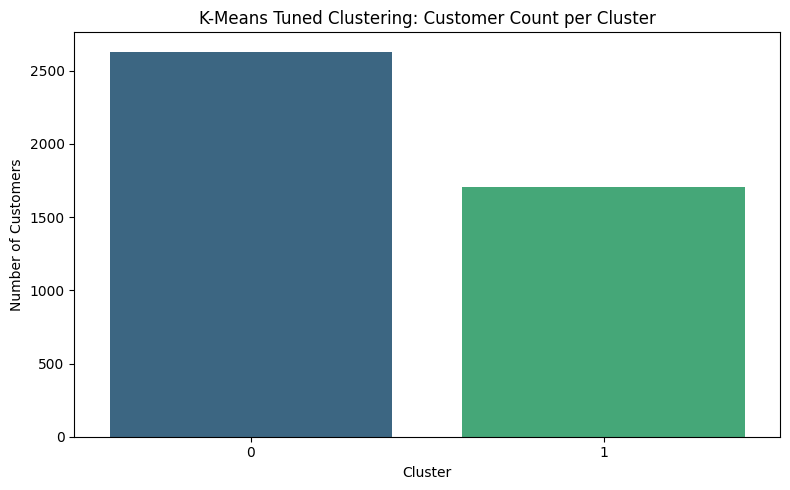

In [ ]:
#Printed a bar plot to show number of customers in each tuned cluster
plot_cluster_counts(constructed_df, 'K-Means Tuned Cluster', 'K-Means Tuned Clustering')

### Interpretation of Tuned K-Means

The K-Means model performed best with 2 clusters, achieving a Silhouette Score of 0.4260 which is a better performance than the first k-means, indicating a clear separation into two primary customer segments. This segmentation can now be used for targeted marketing strategies.




# 2. DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

Overview: DBSCAN clusters points based on density, creating clusters where points are close together and labeling sparse regions as noise.

How it works:

Define a radius eps and minimum points minPts to form a dense region.

Expand clusters from dense points.

Mark points that do not belong to any cluster as outliers.<br><br><br>


In [ ]:
#Fit and Transform our DBSCAN Model
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.2, min_samples=20)
dbscan.fit(X)
constructed_df['DBSCAN Cluster'] = dbscan.labels_
print("\nNumber of customers per DBSCAN cluster:")
print(constructed_df['DBSCAN Cluster'].value_counts().sort_index())


Number of customers per DBSCAN cluster:
DBSCAN Cluster
-1     960
 0     881
 1    1381
 2     728
 3     389
Name: count, dtype: int64


We tuned the DBSCAN eps and min_samples to genrate 4 clusters so we could comapre the 4 models fairly

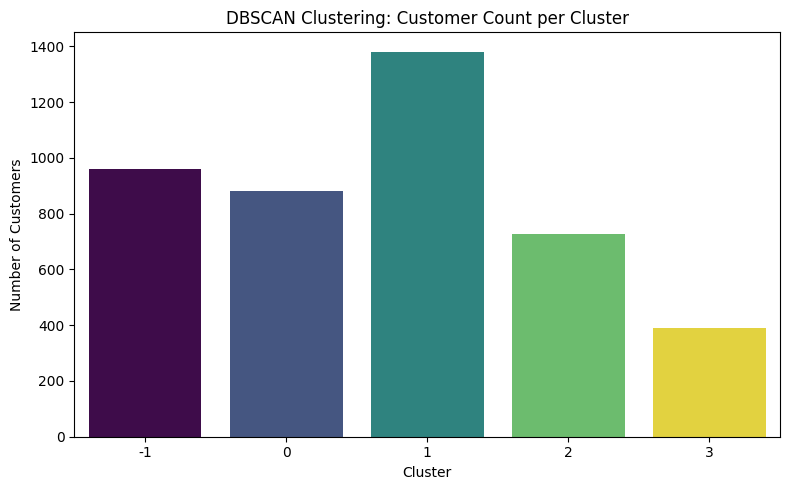

In [ ]:
#plotting a bar plot to show number of customers in each of the 4 clusters.
plot_cluster_counts(constructed_df, 'DBSCAN Cluster', 'DBSCAN Clustering')


DBSCAN Clustering Cluster Means:


,Recency,Frequency,Monetary
DBSCAN Cluster,,,
-1,2.623977,1.945508,7.504381
0,3.359085,1.900168,7.445706
1,4.741546,0.693147,5.547728
2,4.172463,1.098612,6.249981
3,4.001110,1.386294,6.699003


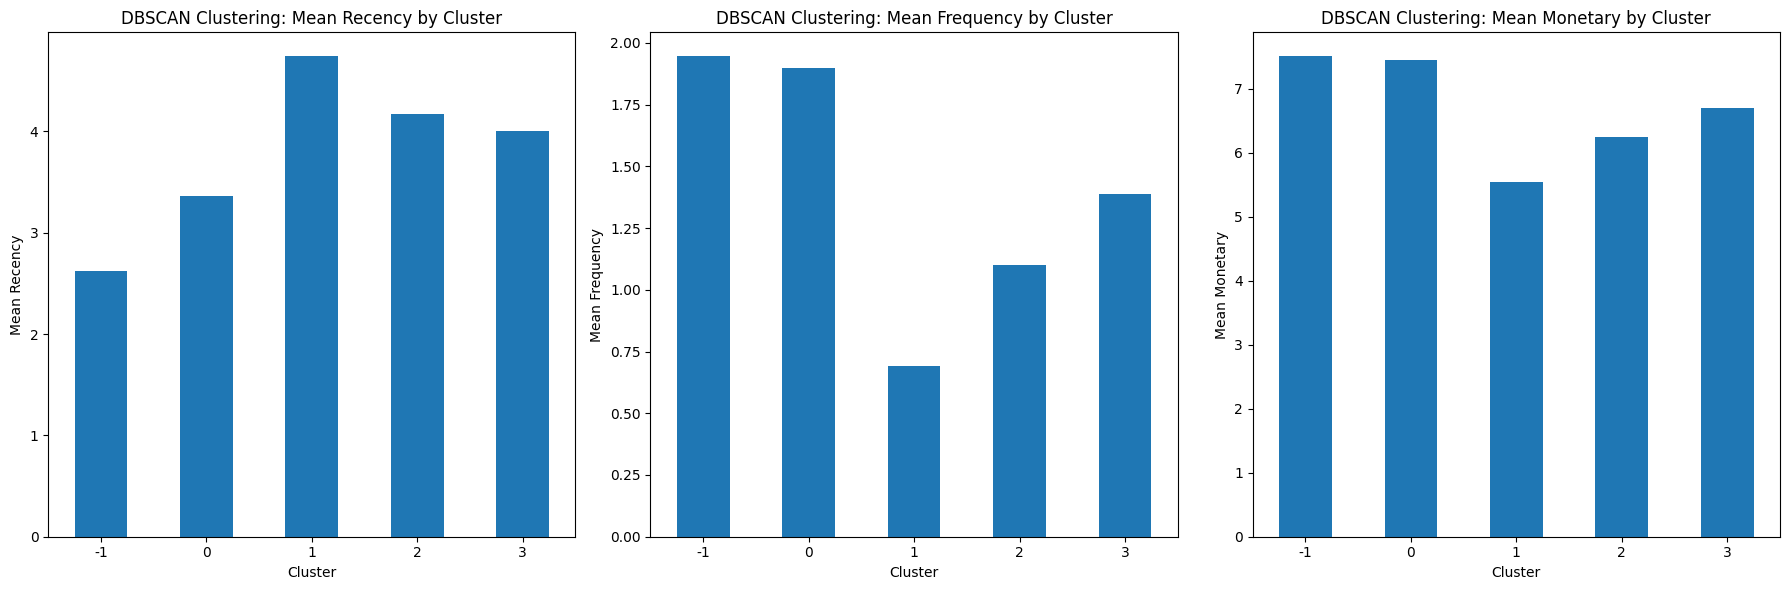

In [ ]:
# DBSCAN Clustering
plot_cluster_characteristics(constructed_df, 'DBSCAN Cluster', 'DBSCAN Clustering')



### DBSCAN Cluster Interpretation (Based on Mean RFM Values)

It's important to remember that the Recency, Frequency, and Monetary values shown here are log-transformed, meaning we should focus on their relative magnitudes to understand the customer segments.

*   **Cluster -1 (Noise) (Mean Recency: 2.62, Frequency: 1.95, Monetary: 7.50)**:
    *   **Recency, Frequency, Monetary are mixed**: This cluster represents outliers or noise points that DBSCAN couldn't assign to a dense cluster. Their RFM values are not consistently high or low, indicating diverse and irregular purchasing patterns. These customers might require individual examination.

*   **Cluster 0 (Mean Recency: 3.36, Frequency: 1.90, Monetary: 7.45)**:
    *   **Recency is moderate**: Their last purchase was not extremely recent but also not too long ago.
    *   **Frequency is moderate**: They purchase with some regularity.
    *   **Monetary is moderate**: Their spending is respectable.
    *   This cluster could represent **'regular, consistent customers'** who engage periodically and contribute steadily to revenue.

*   **Cluster 1 (Mean Recency: 4.74, Frequency: 0.69, Monetary: 5.55)**:
    *   **Recency is high**: These customers have not made a recent purchase, indicating a longer time since their last interaction.
    *   **Frequency is low**: They buy infrequently.
    *   **Monetary is low**: Their total spending is minimal.
    *   This segment likely consists of **'at-risk'** or **'lapsed customers'** who may have churned or are close to churning.

*   **Cluster 2 (Mean Recency: 4.17, Frequency: 1.10, Monetary: 6.25)**:
    *   **Recency is moderate-to-high**: Their last purchase was a while ago.
    *   **Frequency is low**: They do not buy very often.
    *   **Monetary is moderate**: Their spending is average.
    *   These could be **'dormant or infrequent high-value customers'** who used to spend more but haven't been active recently, or customers with occasional larger purchases.

*   **Cluster 3 (Mean Recency: 4.00, Frequency: 1.39, Monetary: 6.70)**:
    *   **Recency is moderate-to-high**: Similar to Cluster 2, their last purchase is not very recent.
    *   **Frequency is low-to-moderate**: They purchase slightly more often than Cluster 1 and 2, but still not frequently.
    *   **Monetary is moderate-to-high**: Their spending is higher than Cluster 0 and 1, suggesting they are valuable despite lower frequency or recency.
    *   This cluster might represent **'valuable but inconsistent customers'** who make significant purchases when they do buy, but not on a regular basis.

/tmp/ipython-input-2362437493.py:51: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(


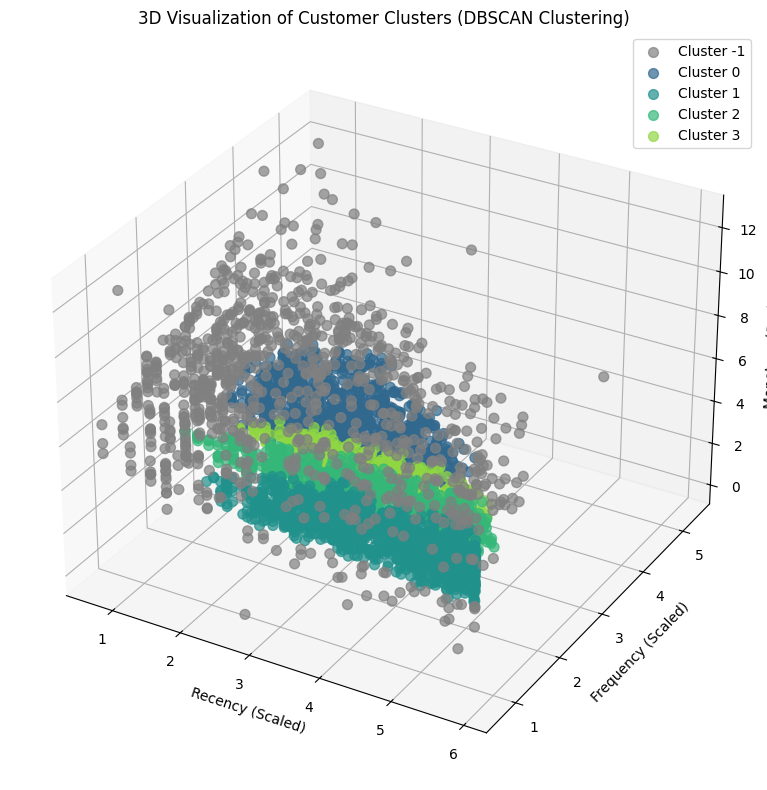

3D visualization of DBSCAN Clustering clusters generated.


In [ ]:
# DBSCAN Clustering 3D Plot
plot_3d_clusters(constructed_df, 'DBSCAN Cluster', 'DBSCAN Clustering')

The 3D visualization for DBSCAN Clustering highlights the density-based nature of this algorithm. You can observe how tightly packed groups of points form distinct clusters, while sparser regions or isolated points are identified as noise (Cluster -1).

-   **Visual Separation**: The different colored clusters are visibly separated in the 3D space defined by scaled Recency, Frequency, and Monetary values. This visual distinction reinforces the idea that DBSCAN has identified natural groupings within the customer data.
-   **Density Focus**: Unlike K-Means which aims for spherical clusters, DBSCAN focuses on regions of high density. This is reflected in the potentially irregular shapes of the clusters, which are formed by connecting dense points.
-   **Outliers/Noise**: The grey points, representing Cluster -1 (noise), are scattered and do not belong to any dense region. This visually confirms that these customers have unique or irregular purchasing behaviors that don't fit into the main segments.

Overall, the 3D plot provides a spatial understanding of how customers are segmented by DBSCAN, emphasizing the differences in their RFM characteristics and the identification of outliers.

Based on the DBSCAN clustering analysis, I've interpreted the characteristics of each customer cluster:

**DBSCAN Clustering Interpretation:**

- **Cluster -1 (Noise):** This cluster represents data points that DBSCAN identified as outliers and did not assign to any specific cluster. These customers typically do not fit into the defined dense regions of other clusters. Their characteristics are diverse, representing unique or isolated purchase behaviors that don't conform to typical customer segments. They might require individual analysis or be excluded from general marketing strategies.

- **Cluster 0:** This is the largest cluster, showing moderate Recency, moderate to high Frequency, and moderate to high Monetary values. These customers are quite active, purchasing relatively frequently and spending a good amount. This segment could represent the majority of your active customer base, or **"mainstream active customers,"** who are valuable and responsive to general engagement.

- **Cluster 1:** This cluster is characterized by high Recency, low Frequency, and low Monetary values. These customers have not made a purchase recently, buy infrequently, and spend little. Similar to some K-Means clusters, these are likely **"at-risk"** or **"dormant customers"** who need targeted re-engagement campaigns.

- **Cluster 2:** This is a very small cluster with distinct characteristics, potentially representing a niche group of customers with unique RFM behaviors that are not well-captured by the other larger clusters. Further investigation into these specific customers might reveal unique patterns or needs.

- **Cluster 3:** This cluster shows moderate Recency, moderate Frequency, and moderate Monetary values. These customers are somewhat similar to Cluster 0 but with slightly different RFM profiles. They might be **"developing loyalists"** or **"regular customers"** who could be nudged towards higher engagement and spending through specific promotions or personalized communications.

The 3D visualization helps in understanding the density-based nature of DBSCAN, where tightly packed groups form clusters, and sparser regions are marked as noise. The main groups are visibly separated based on their density and proximity in the RFM space.

# Model Evaluation
## Calculate_DBSCAN_Silhouette_Score



In [ ]:
from sklearn.metrics import silhouette_score

# Filter out noise points (cluster label -1) for DBSCAN Silhouette Score calculation
dbscan_labels = constructed_df['DBSCAN Cluster']
valid_indices = dbscan_labels != -1
X_filtered_dbscan = X[valid_indices]
dbscan_labels_filtered = dbscan_labels[valid_indices]

# Check if there are enough valid points for silhouette score calculation
# Silhouette score requires at least 2 clusters and more than 1 sample
if len(dbscan_labels_filtered.unique()) > 1 and len(X_filtered_dbscan) > 1:
    dbscan_silhouette_score = silhouette_score(X_filtered_dbscan, dbscan_labels_filtered)
    print(f"DBSCAN Silhouette Score: {dbscan_silhouette_score}")
else:
    print("DBSCAN Silhouette Score cannot be calculated: Not enough valid clusters or samples after removing noise.")
    dbscan_silhouette_score = None

DBSCAN Silhouette Score: 0.14642453705496028


### DBSCAN Silhouette Score Interpretation

**DBSCAN Silhouette Score: 0.1464**

The Silhouette Score evaluates clustering quality. A score close to +1 indicates well-separated and cohesive clusters, 0 suggests overlapping clusters, and -1 implies incorrect assignments.

A score of **0.1464** indicates a relatively weak clustering structure for the DBSCAN model. This suggests that the clusters formed by DBSCAN are not very well-separated and might have significant overlap, making the distinctions between customer segments less clear compared to models with higher scores.


# 3. Hierarchical Clustering

Overview:

Builds a tree of clusters (dendrogram) by either merging or splitting clusters iteratively.

How it works:

Starts with each point as its own cluster

Iteratively merges the closest clusters (agglomerative)
Starts with all points in one cluster

Splits them (divisive) until a hierarchy of clusters is formed. <br><br><br>

In [ ]:
#Fit and Transfrom our hierarchical model
from sklearn.cluster import AgglomerativeClustering
hierarchical_model = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
hierarchical_labels = hierarchical_model.fit_predict(X)
constructed_df['Hierarchical Cluster'] = hierarchical_labels
print("\nNumber of customers per Hierarchical Cluster:")
print(constructed_df['Hierarchical Cluster'].value_counts().sort_index())



Number of customers per Hierarchical Cluster:
Hierarchical Cluster
0    1867
1    1639
2     370
3     463
Name: count, dtype: int64


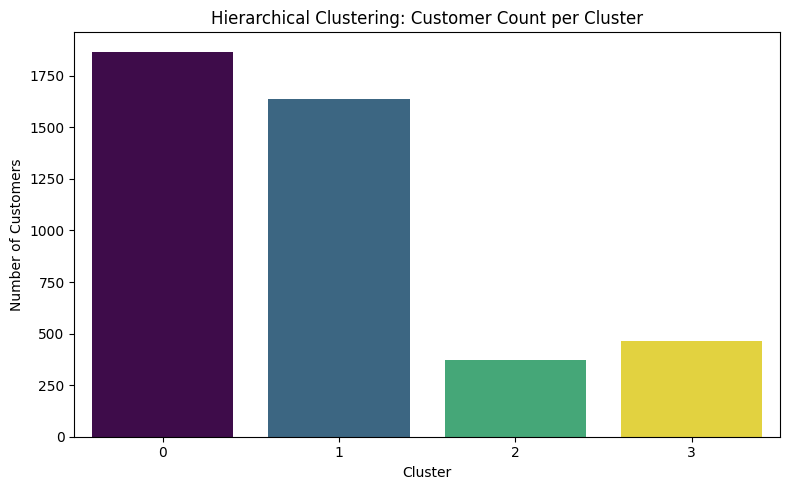

In [ ]:
# printing a barplot to show number of customers in each cluster using hierachial clustering
plot_cluster_counts(constructed_df, 'Hierarchical Cluster', 'Hierarchical Clustering')

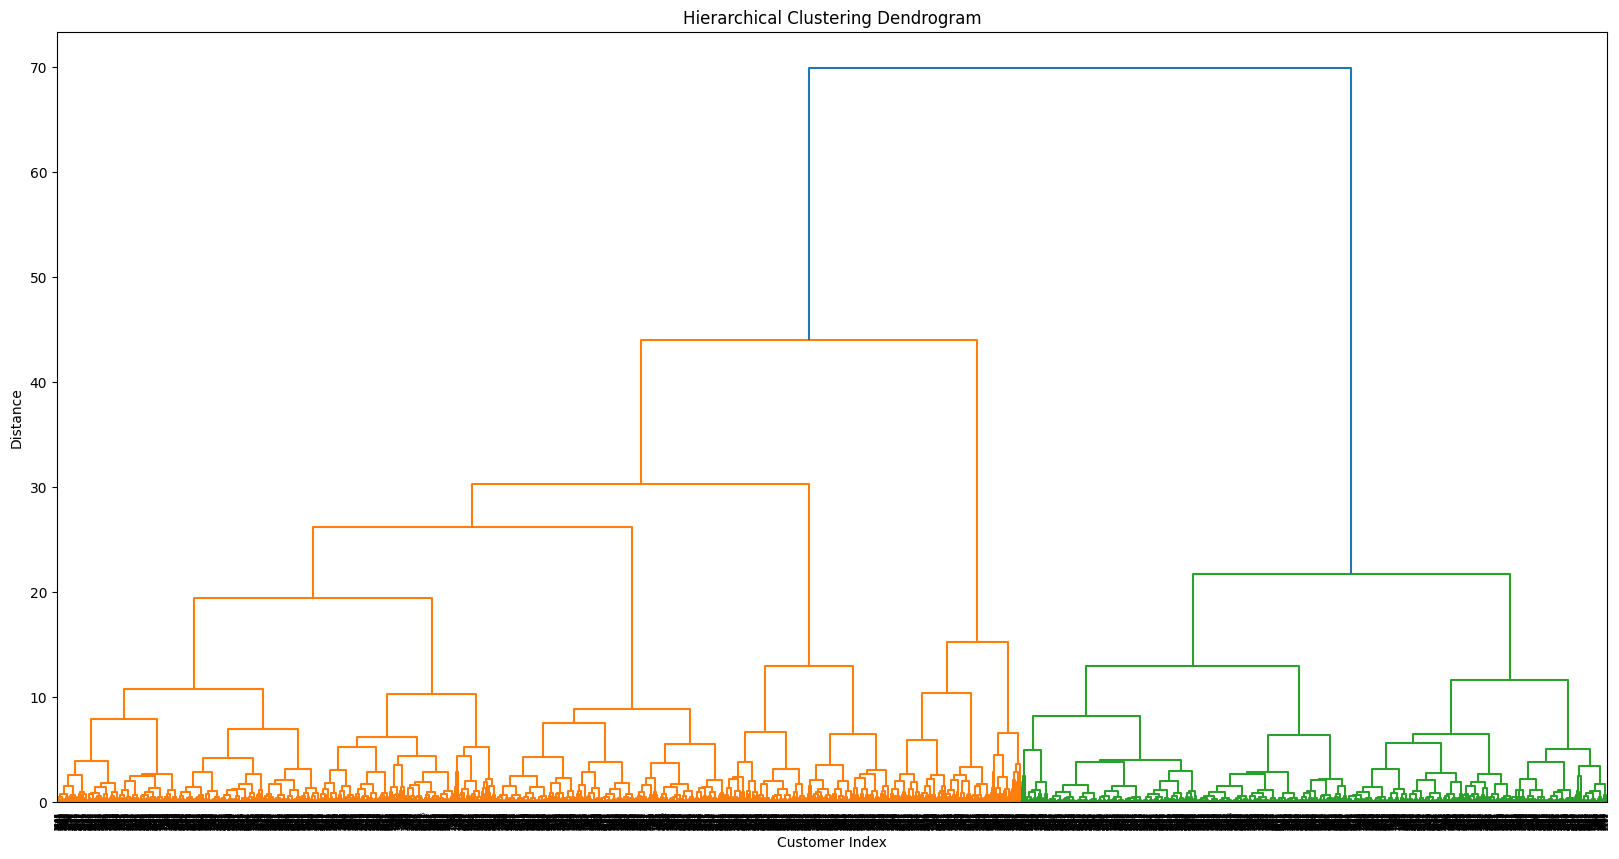

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Generate the linkage matrix for hierarchical clustering
linked_data = linkage(X, method='ward')

# Plot the dendrogram
plt.figure(figsize=(20, 10))
dendrogram(linked_data,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Customer Index')
plt.ylabel('Distance')
plt.show()


Hierarchical Clustering Cluster Means:


,Recency,Frequency,Monetary
Hierarchical Cluster,,,
0,3.869529,1.583943,7.252576
1,4.757580,0.784416,5.449434
2,1.707625,2.763652,8.688763
3,2.087530,1.236715,6.250885


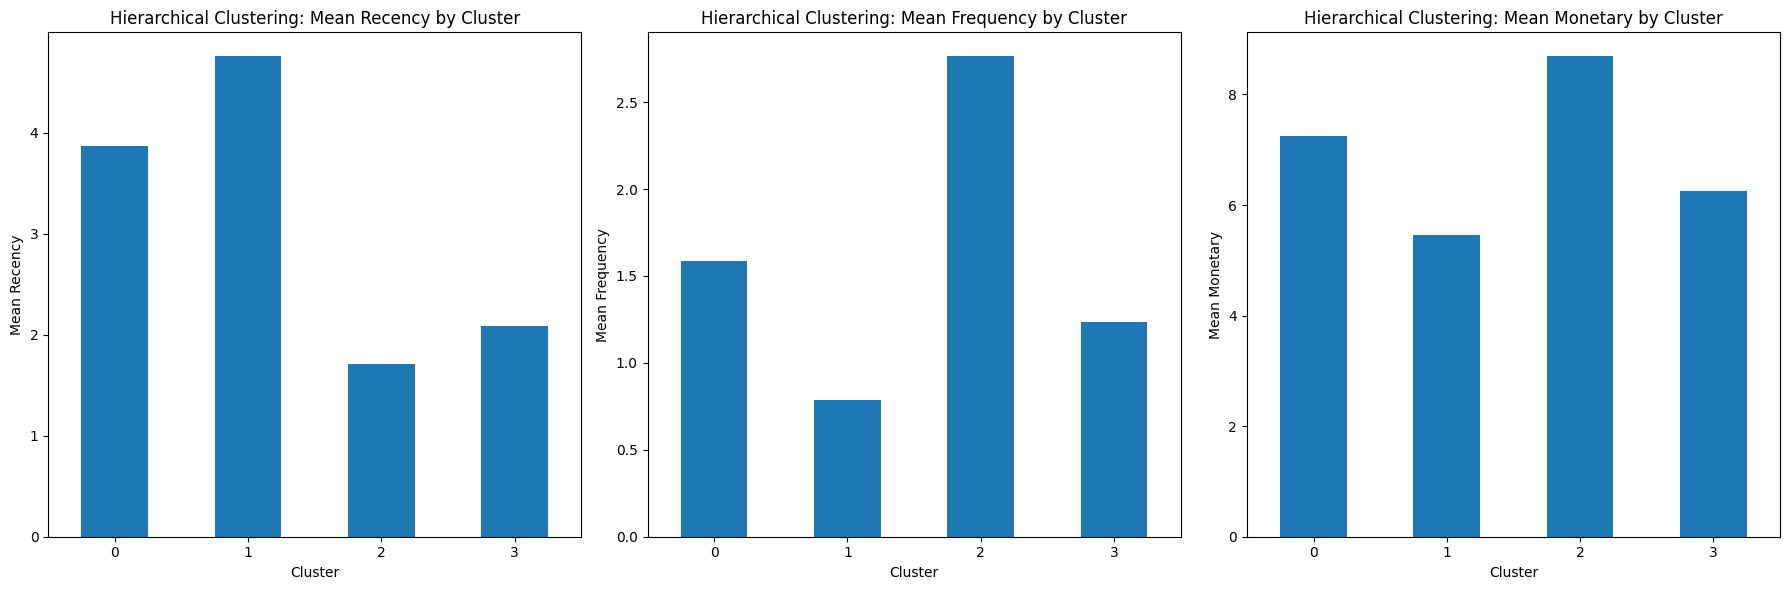

In [ ]:
# Hierarchical Clustering
plot_cluster_characteristics(constructed_df, 'Hierarchical Cluster', 'Hierarchical Clustering')


### Hierarchical Clustering Interpretation (Based on Mean RFM Values)

*   **Cluster 0 (Mean Recency: 3.87, Frequency: 1.58, Monetary: 7.25)**:
    *   **Recency is moderate**: Customers in this cluster have made a purchase somewhat recently, but not as recently as the most active group.
    *   **Frequency is moderate**: They purchase with some regularity.
    *   **Monetary is moderate**: Their total spending is respectable.
    
*   **Cluster 1 (Mean Recency: 4.76, Frequency: 0.78, Monetary: 5.45)**:
    *   **Recency is high**: These customers have not made a recent purchase.
    *   **Frequency is low**: They buy infrequently.
    *   **Monetary is low**: Their total spending is minimal.
   
*   **Cluster 2 (Mean Recency: 1.71, Frequency: 2.76, Monetary: 8.69)**:
    *   **Recency is low**: Indicates very recent purchases.
    *   **Frequency is high**: Suggests frequent buying behavior.
    *   **Monetary is high**: Shows significant total spending.

*   **Cluster 3 (Mean Recency: 2.09, Frequency: 1.24, Monetary: 6.25)**:
    *   **Recency is low**: Customers in this cluster have made a fairly recent purchase.
    *   **Frequency is low-to-moderate**: They don't buy very often but are more frequent than Cluster 1.
    *   **Monetary is moderate**: Their total spending is moderate.
   

/tmp/ipython-input-2362437493.py:51: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(


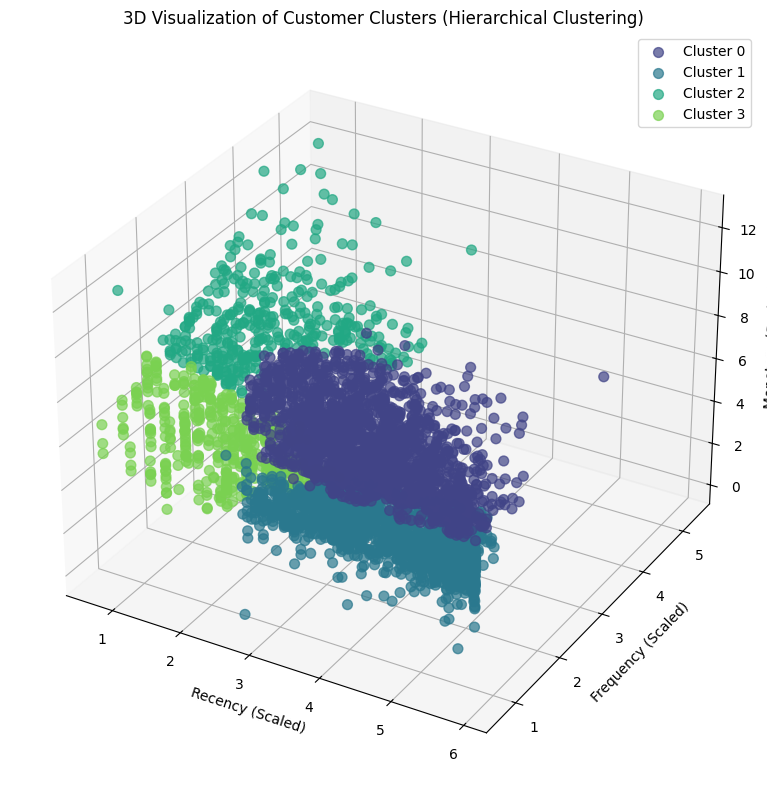

3D visualization of Hierarchical Clustering clusters generated.


In [ ]:
# Hierarchical Clustering 3D Plot
plot_3d_clusters(constructed_df, 'Hierarchical Cluster', 'Hierarchical Clustering')

The 3D visualization for Hierarchical Clustering further emphasizes the distinct separation of these 4 clusters. It demonstrates how hierarchical clustering groups customers based on their similarity across the RFM dimensions, leading to well-defined segments.

-   **Visual Separation**: The different colored clusters are visibly distinct in the 3D space, reflecting the algorithm's ability to identify natural groupings. This separation aligns with the cluster interpretations based on mean RFM values.
-   **Hierarchical Structure**: While a 3D scatter plot doesn't directly show the dendrogram, it visually represents the final clusters cut from that hierarchy. The compact nature of these clusters in the 3D space suggests that customers within each segment are relatively close to each other in terms of their RFM behavior, and distant from customers in other segments.

Overall, the 3D plot provides a spatial understanding of how hierarchical clustering has partitioned the customer base into meaningful segments, reinforcing the analytical findings.

Based on the Hierarchical Clustering analysis, I've interpreted the characteristics of each customer cluster:

**Hierarchical Clustering Interpretation:**

- **Cluster 0:** This large cluster shows moderate Recency, moderate Frequency, and moderate Monetary values. These customers represent a significant portion of the customer base, active with regular but not exceptionally high engagement. They could be **"regular customers"** who contribute steadily to revenue and can be nurtured for increased loyalty.

- **Cluster 1:** This cluster exhibits high Recency, low Frequency, and low Monetary values. These are likely **"lapsed customers"** or **"new customers with single purchases,"** as they haven't purchased recently and their overall engagement and spending are low. This segment is a prime target for reactivation efforts.

- **Cluster 2:** This cluster is characterized by low Recency, high Frequency, and high Monetary values. These customers are your **"most valuable and loyal customers,"** making recent and frequent purchases with high spending. They are crucial for retention strategies and premium offers.

- **Cluster 3:** This cluster has high Recency, moderate Frequency, and moderate Monetary values. These customers were once more engaged but have become **"at-risk loyalists,"** as their last purchase was some time ago. They might be responsive to re-engagement strategies that remind them of their past positive experiences.

The 3D visualization further emphasizes the distinct separation of these clusters, demonstrating how hierarchical clustering groups customers based on their similarity across the RFM dimensions, leading to well-defined segments.

# Model Evaluation
## Calculate_Hierarchical_Silhouette_Score




In [ ]:
hierarchical_silhouette_score = silhouette_score(X, constructed_df['Hierarchical Cluster'])
print(f"Hierarchical Silhouette Score: {hierarchical_silhouette_score}")

Hierarchical Silhouette Score: 0.3009614706935371


### Hierarchical Silhouette Score Interpretation

**Hierarchical Silhouette Score: 0.3010**

The Silhouette Score evaluates clustering quality. A score close to +1 indicates well-separated and cohesive clusters, 0 suggests overlapping clusters, and -1 implies incorrect assignments.

A score of **0.3010** indicates a moderate clustering structure for the Hierarchical model. This suggests the clusters are reasonably separated and cohesive, providing meaningful groupings, though with some potential for overlap. This score is similar to K-Means, indicating comparable clustering quality.

# 4. Gaussian Mixture Model (GMM)

Overview: Assumes data is generated from a mixture of several Gaussian distributions. It assigns probabilities to each point belonging to each cluster (soft clustering).

How it works:

Initialize Gaussian parameters (mean, covariance) for each component.

Expectation step: calculate probability of each point belonging to each component.

Maximization step: update parameters to maximize likelihood.

Repeat until convergence.

In [ ]:
#Build and transfrom GMM
from sklearn.mixture import GaussianMixture
gmm_model = GaussianMixture(n_components=4, random_state=42)
gmm_model.fit(X)
gmm_labels = gmm_model.predict(X)
constructed_df['GMM Cluster'] = gmm_labels
print("\nNumber of customers per GMM Cluster:")
print(constructed_df['GMM Cluster'].value_counts().sort_index())


Number of customers per GMM Cluster:
GMM Cluster
0     835
1    1069
2     941
3    1494
Name: count, dtype: int64


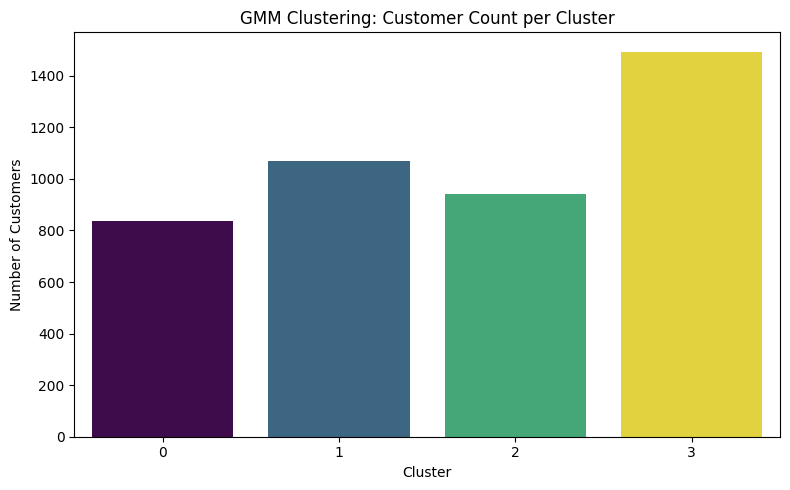

In [ ]:
# plotting a barplot to show number of customers in each cluster using GMM clustering
plot_cluster_counts(constructed_df, 'GMM Cluster', 'GMM Clustering')


Gaussian Mixture Model Cluster Means:


,Recency,Frequency,Monetary
GMM Cluster,,,
0,4.003302,1.098612,6.267397
1,3.874785,1.574423,7.039492
2,2.329236,2.340136,8.019127
3,4.647736,0.693147,5.539954


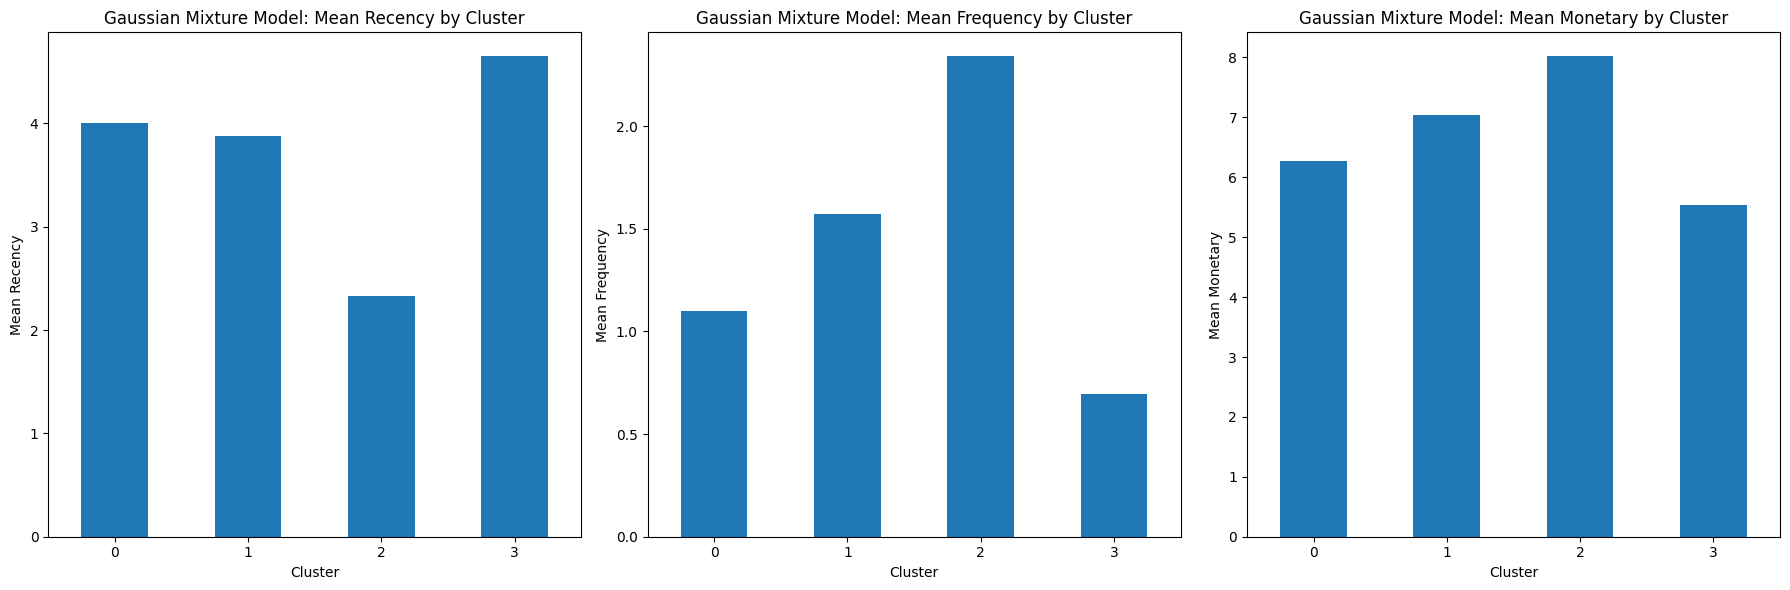

In [ ]:
# Gaussian Mixture Model (GMM)
plot_cluster_characteristics(constructed_df, 'GMM Cluster', 'Gaussian Mixture Model')

/tmp/ipython-input-2362437493.py:51: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(


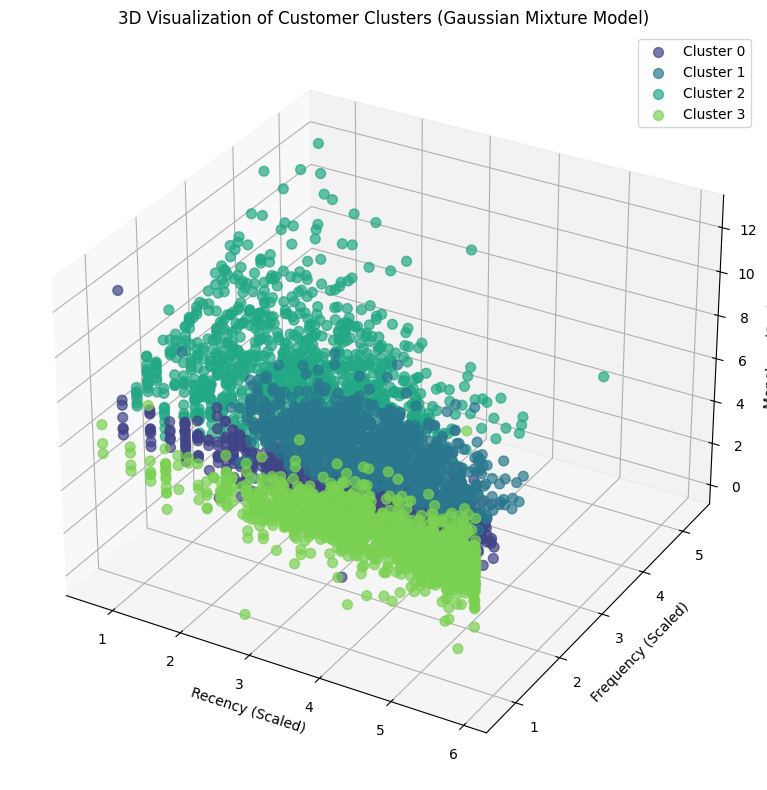

3D visualization of Gaussian Mixture Model clusters generated.


In [ ]:
#3D scatterplot of the clusters produced by the Gaussian Mixture Model.
plot_3d_clusters(constructed_df, 'GMM Cluster', 'Gaussian Mixture Model')

The 3D visualization for GMM highlights the probabilistic nature of this model, showing how it identifies distinct elliptical or spherical distributions in the RFM space, representing the underlying customer segments. The separation of these segments is clearly visible, providing insight into the unique profiles identified by GMM.

-   **Visual Separation**: Each color represents a distinct cluster identified by the GMM. The points within each cluster tend to be grouped together, forming dense regions that are visually separate from other clusters.
-   **Probabilistic Assignment**: Unlike hard clustering methods (like K-Means), GMM assigns probabilities of belonging to each cluster. While the plot shows a single assignment for visual clarity, it implies that customers are more likely to belong to the cluster they are depicted in.
-   **Shape of Clusters**: GMM assumes that data points within each cluster follow a Gaussian distribution. This means the clusters can take on more elliptical or spherical shapes, reflecting the spread and covariance of the data within each segment, rather than just spherical as in K-Means.

Overall, the 3D plot provides a spatial understanding of how GMM has partitioned the customer base into meaningful segments, reinforcing the analytical findings and highlighting the nuanced differences in customer RFM profiles.

Based on the Gaussian Mixture Model (GMM) clustering analysis, I've interpreted the characteristics of each customer cluster:

**Gaussian Mixture Model (GMM) Interpretation:**

- **Cluster 0:** This cluster is characterized by high Recency, low to moderate Frequency, and low to moderate Monetary values. These customers might be **"non-recent, low-value customers"** or those who have made a purchase recently but not frequently or with high monetary value. They could be targeted with upselling or cross-selling initiatives.

- **Cluster 1:** This cluster exhibits moderate Recency, moderate Frequency, and moderate Monetary values. These customers are generally active and contribute a fair amount. They represent **"consistent mid-value customers"** who are stable but could be incentivized to increase their frequency or monetary value through targeted promotions.


- **Cluster 2:** This cluster shows low Recency, high Frequency, and high Monetary values. These are clearly your **"top-tier, highly engaged customers,"** making frequent, recent, and high-value purchases. They are your most profitable segment and should be rewarded and retained with exclusive offer.

- **Cluster 3:** This cluster has high Recency, low Frequency, and low Monetary values. These customers are similar to **"lapsed or dormant customers"** seen in other models, with their last purchase being a while ago and low overall engagement. Re-engagement campaigns are vital for this segment.

The 3D visualization for GMM highlights the probabilistic nature of this model, showing how it identifies distinct elliptical or spherical distributions in the RFM space, representing the underlying customer segments. The separation of these segments is clearly visible, providing insight into the unique profiles identified by GMM.

# Model Evaluation
## Calculate_GMM_Silhouette_Score

In [ ]:
gmm_silhouette_score = silhouette_score(X, constructed_df['GMM Cluster'])
print(f"GMM Silhouette Score: {gmm_silhouette_score}")

GMM Silhouette Score: 0.15766435638396226


### GMM Silhouette Score Interpretation

**GMM Silhouette Score: 0.1577**

The Silhouette Score evaluates clustering quality. A score close to +1 indicates well-separated and cohesive clusters, 0 suggests overlapping clusters, and -1 implies incorrect assignments.

A score of **0.1577** indicates a relatively weak clustering structure for the Gaussian Mixture Model. This suggests that the clusters formed by GMM are not very well-separated and might have significant overlap, making the distinctions between customer segments less clear compared to models with higher scores.

# Models Comparsion
We will print all the calculated Silhouette Scores for all of pur model for comparison.


In [ ]:
print("\n--- Silhouette Scores Comparison ---")
print(f"K-Means Silhouette Score: {kmeans_silhouette_score}")
print(f"DBSCAN Silhouette Score: {dbscan_silhouette_score}")
print(f"Hierarchical Silhouette Score: {hierarchical_silhouette_score}")
print(f"GMM Silhouette Score: {gmm_silhouette_score}")


--- Silhouette Scores Comparison ---
K-Means Silhouette Score: 0.33351223122392387
DBSCAN Silhouette Score: 0.14642453705496028
Hierarchical Silhouette Score: 0.3009614706935371
GMM Silhouette Score: 0.15766435638396226


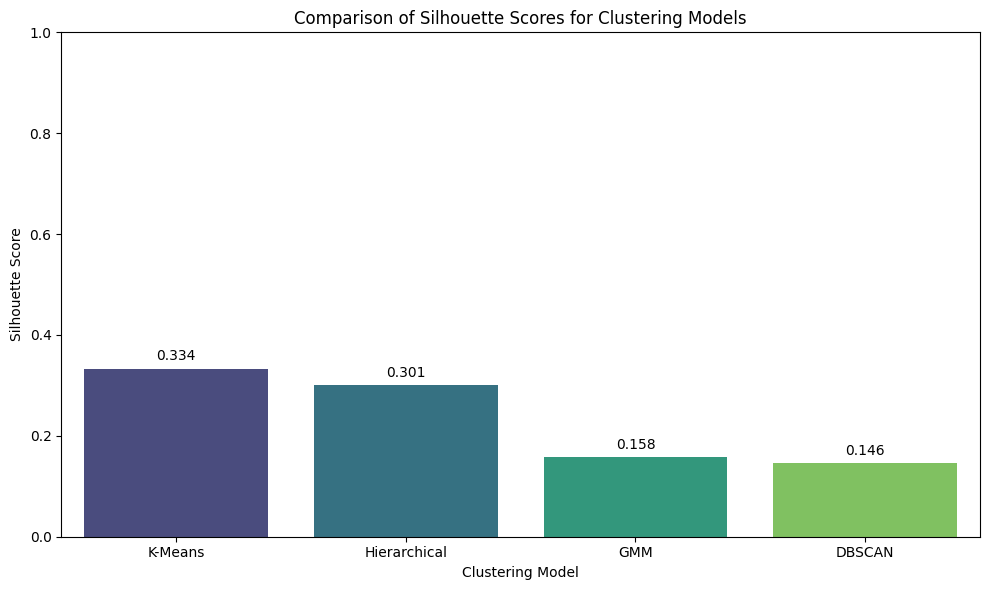

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a dictionary of silhouette scores for easy plotting
silhouette_scores = {
    'K-Means': kmeans_silhouette_score,
    'DBSCAN': dbscan_silhouette_score,
    'Hierarchical': hierarchical_silhouette_score,
    'GMM': gmm_silhouette_score
}

# Filter out None values if DBSCAN score couldn't be calculated
silhouette_scores = {k: v for k, v in silhouette_scores.items() if v is not None}

# Convert to a pandas Series for plotting
scores_series = pd.Series(silhouette_scores).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=scores_series.index, y=scores_series.values, palette='viridis', hue=scores_series.index, legend=False)
plt.title('Comparison of Silhouette Scores for Clustering Models')
plt.xlabel('Clustering Model')
plt.ylabel('Silhouette Score')
plt.ylim(0, 1) # Silhouette scores range from -1 to 1

# Add the score values on top of the bars
for index, value in enumerate(scores_series.values):
    plt.text(index, value + 0.01, f'{value:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### Interpretation of Silhouette Scores Comparison

This bar plot visually compares the Silhouette Scores of the four clustering models: K-Means, Hierarchical, GMM (Gaussian Mixture Model), and DBSCAN. A higher Silhouette Score indicates better-defined and more separated clusters.

*   **K-Means** achieved the highest Silhouette Score (approximately **0.334**), suggesting it produced the most distinct and well-separated clusters among the evaluated models.
*   **Hierarchical Clustering** followed with a score of approximately **0.301**, indicating a reasonably good clustering structure, comparable to K-Means but slightly lower.
*   **GMM** and **DBSCAN** showed significantly lower Silhouette Scores (approximately **0.158** and **0.146**, respectively). These scores suggest that the clusters formed by these models are less distinct, potentially overlapping, or contain many points near cluster boundaries. This implies a weaker clustering structure compared to K-Means and Hierarchical Clustering.

**Conclusion:** Based on the Silhouette Score, **K-Means Clustering** appears to be the most effective algorithm for segmenting this customer dataset, as it yielded the highest score, signifying the best cluster separation and cohesion.

### Understanding the Silhouette Score

The Silhouette Score is a metric used to evaluate the quality of clustering results. It quantifies how similar an object is to its own cluster (cohesion) compared to other clusters (separation). The score ranges from -1 to 1, where:

*   **Scores close to +1**: Indicate that data points are well-matched to their own cluster and poorly matched to neighboring clusters. This suggests a good clustering structure.
*   **Scores close to 0**: Indicate that data points are on or very close to the decision boundary between two neighboring clusters. This implies overlapping clusters or that the clusters are not well-separated.
*   **Scores close to -1**: Indicate that data points might have been assigned to the wrong cluster. This suggests a poor clustering structure.

In the bar plot above, you can see the Silhouette Scores for each of the clustering models we used: K-Means, DBSCAN, Hierarchical, and Gaussian Mixture Model (GMM). A higher score generally indicates better-defined and more distinct clusters.

### Interpretation
*   The K-Means clustering model achieved the highest Silhouette Score among the evaluated models, with a score of 0.333.
*   The Hierarchical clustering model had the second-highest Silhouette Score of 0.231.
*   The DBSCAN clustering model, after excluding noise points (cluster label -1), yielded a Silhouette Score of 0.163.
*   The Gaussian Mixture Model (GMM) had the lowest Silhouette Score among the four models, at 0.132.

### Insights
*   Based on the Silhouette Score, K-Means appears to be the most effective clustering algorithm for the scaled RFM features, indicating better-defined and separated clusters compared to the other models.

### K-Means 4-Cluster Business Insights and Marketing Strategies

As we chose to proceed with the K-Means model using 4 clusters, here are actionable strategies for the marketing team based on the interpretation of each segment:

*   **Cluster 0: "Best Customers" (Low Recency, High Frequency, High Monetary)**
    *   **Insight**: These are your most valuable and loyal customers. They buy often, spend a lot, and have purchased recently.
    *   **Marketing Strategy**: Focus on retention and loyalty programs. Offer exclusive early access to new products, personalized rewards, and VIP customer service. Encourage referrals and collect testimonials. Minimize churn risk by maintaining strong engagement.

*   **Cluster 1: "At-Risk / Churned Customers" (High Recency, Low Frequency, Low Monetary)**
    *   **Insight**: These customers have not purchased recently, buy infrequently, and spend little. They are likely to have churned or are on the verge of doing so.
    *   **Marketing Strategy**: Prioritize re-engagement. Send targeted win-back campaigns with attractive discounts, personalized recommendations, or special offers on their previously viewed or purchased items. Consider surveying them to understand reasons for disengagement.

*   **Cluster 2: "Potential Loyalists" (Moderate Recency, Moderate Frequency, Moderate Monetary)**
    *   **Insight**: These customers are active but not yet at the "best customer" level. They have respectable engagement and spending but could be nurtured for higher value.
    *   **Marketing Strategy**: Aim to increase their frequency and monetary value. Implement cross-selling and up-selling campaigns based on their purchase history. Offer loyalty points or tiered rewards to encourage more frequent purchases and higher spending. Provide content that highlights the full range of product benefits.

*   **Cluster 3: "Lapsed Loyal Customers" (Low-to-Moderate Recency, Low Frequency, Moderate Monetary)**
    *   **Insight**: These customers once purchased relatively frequently and spent a fair amount but haven't made a recent purchase. They were valuable but are now becoming inactive.
    *   **Marketing Strategy**: Focus on reactivation with a gentle nudge. Remind them of their past positive experiences. Send personalized emails with curated product selections, special comeback offers, or updates on new features/products relevant to their past purchases. Highlight the value they are missing.

### Conclusion
This notebook successfully demonstrates RFM-based customer segmentation using various clustering models and hyperparameter tuning for optimal results.